
=== 0.4 kV ===
U_LL,s = 400.0 V
I(10°C) = 200.0 A
cos(phi)(10°C) = 0.950
R20_kabel = 0.030000 ohm
X_kabel = 0.008000 ohm
Beräknad fast last: Z_load = 1.068175 + j0.352555 ohm

Vid 10 °C:
  R_kabel(10)      = 0.028791 ohm
  I_exact(10)      = 200.000000 A
  Vr_LL_exact(10)  = 389.66 V
  Vr_ang_exact(10) = 0.070801 deg
  P_loss(10)       = 3454.92 W

Vid 90 °C:
  R_kabel(90)      = 0.038463 ohm
  I_exact(90)      = 198.420418 A
  Vr_LL_exact(90)  = 386.58 V
  Vr_ang_exact(90) = 0.219473 deg
  P_loss(90)       = 4542.94 W

Skillnad 10 -> 90 °C:
  Delta I          = -1.579582 A
  Delta Vr_LL      = -3.08 V
  Delta Vr_ang     = 0.148672 deg
  Delta P_loss     = 1088.02 W

=== 11 kV ===
U_LL,s = 11000.0 V
I(10°C) = 200.0 A
cos(phi)(10°C) = 0.950
R20_kabel = 0.800000 ohm
X_kabel = 0.450000 ohm
Beräknad fast last: Z_load = 29.398792 + j9.465266 ohm

Vid 10 °C:
  R_kabel(10)      = 0.767760 ohm
  I_exact(10)      = 200.000000 A
  Vr_LL_exact(10)  = 10698.86 V
  Vr_ang_exact(10) = -0.348335 deg

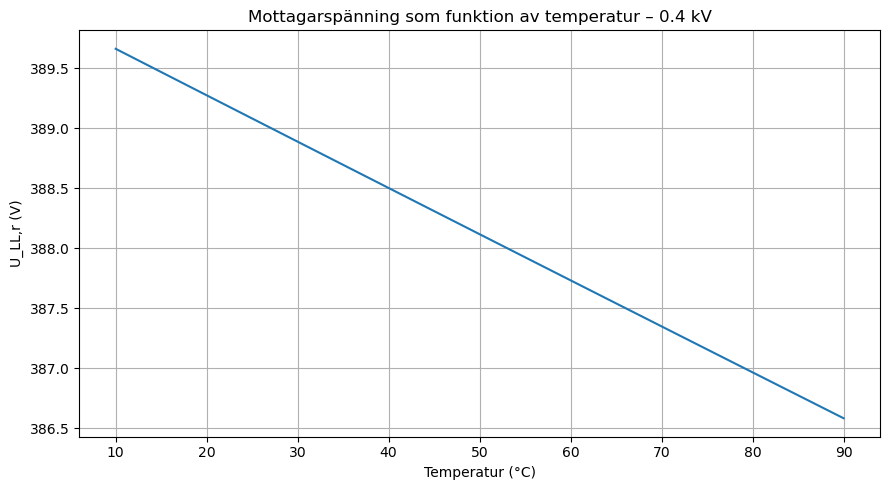

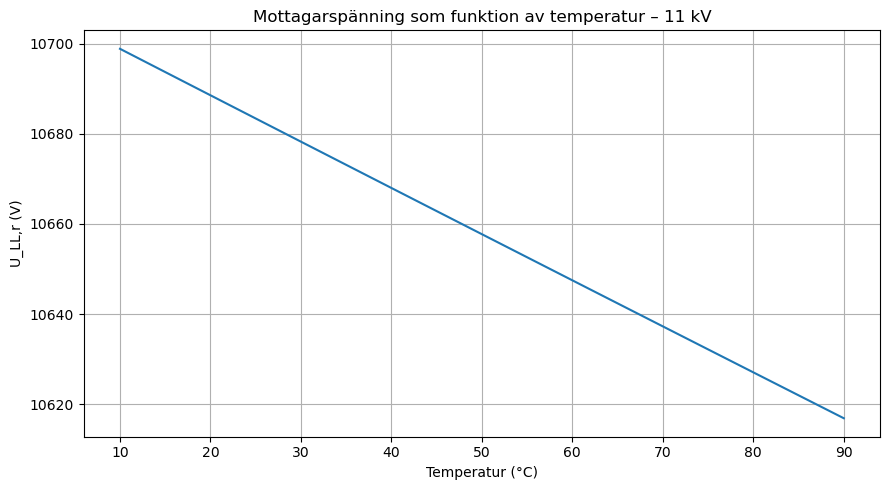

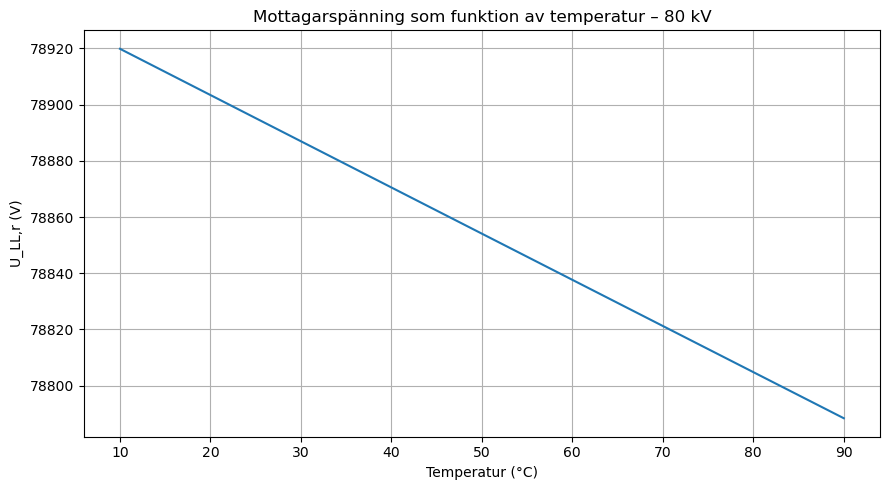

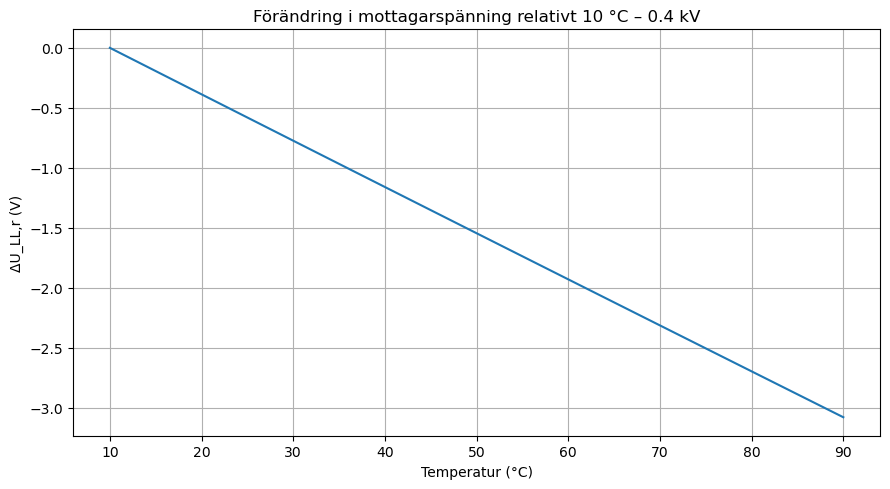

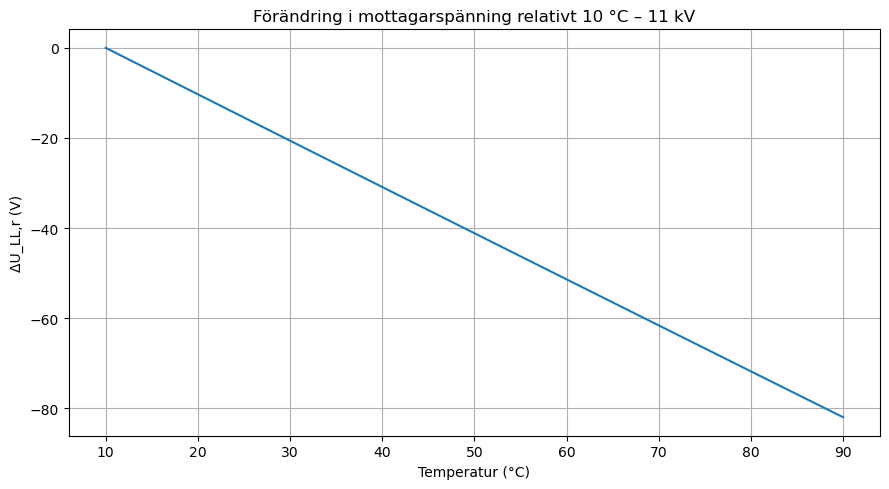

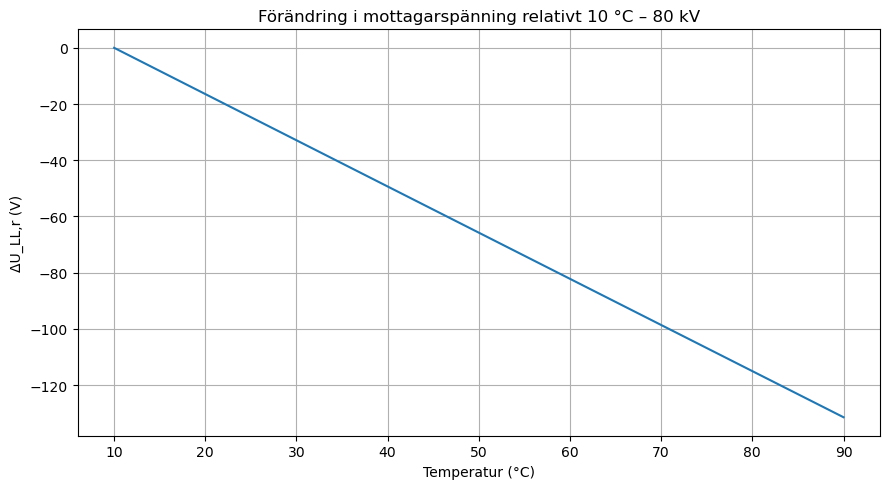

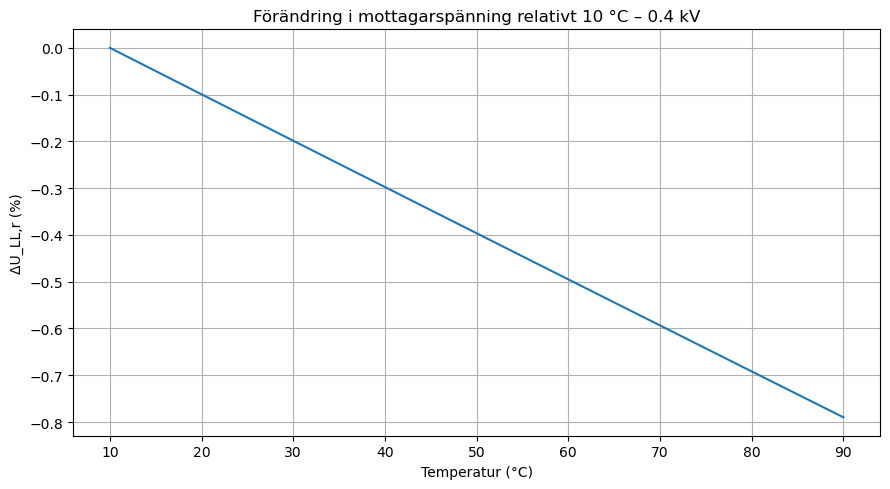

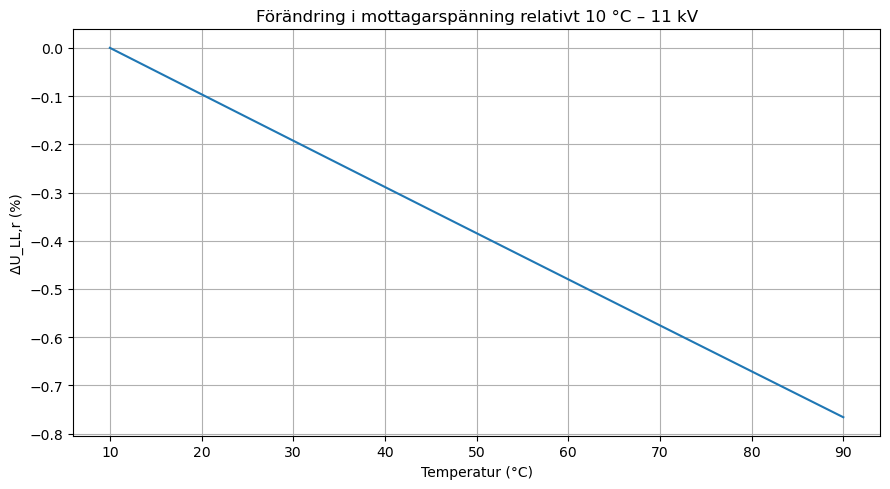

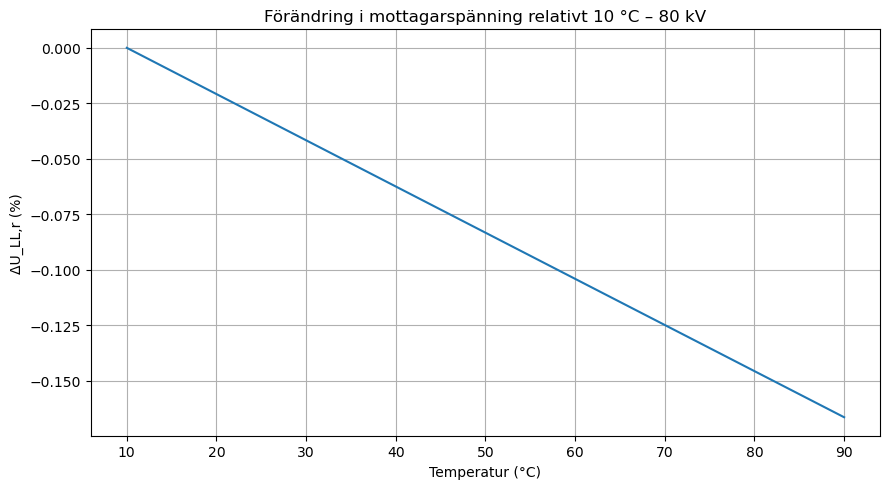

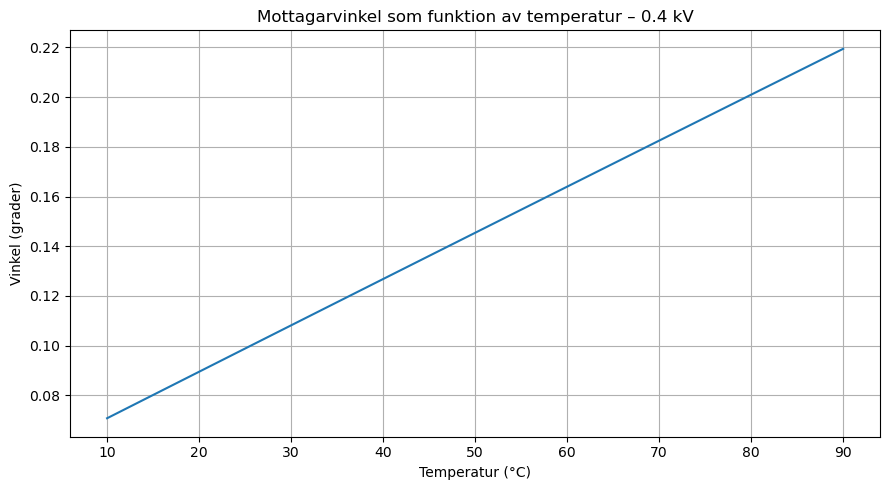

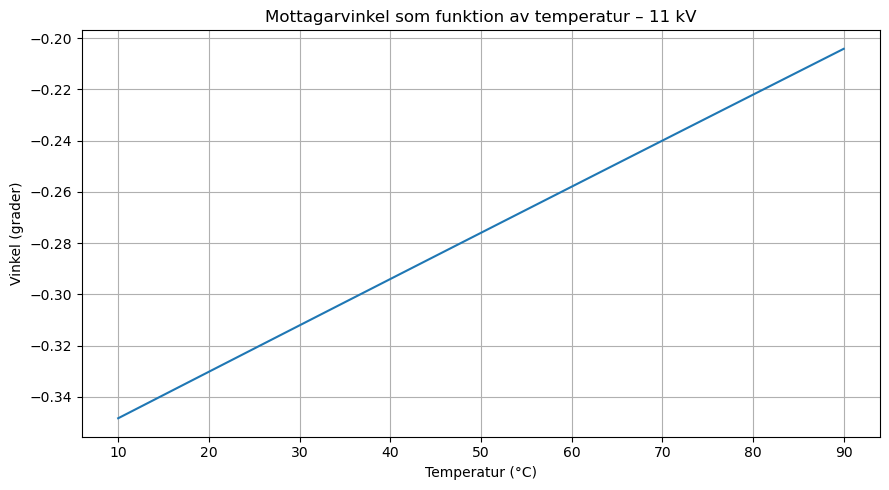

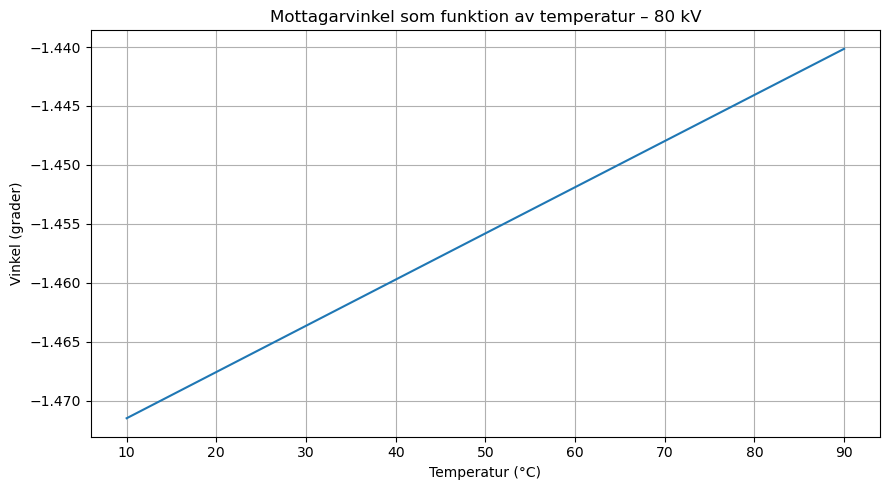

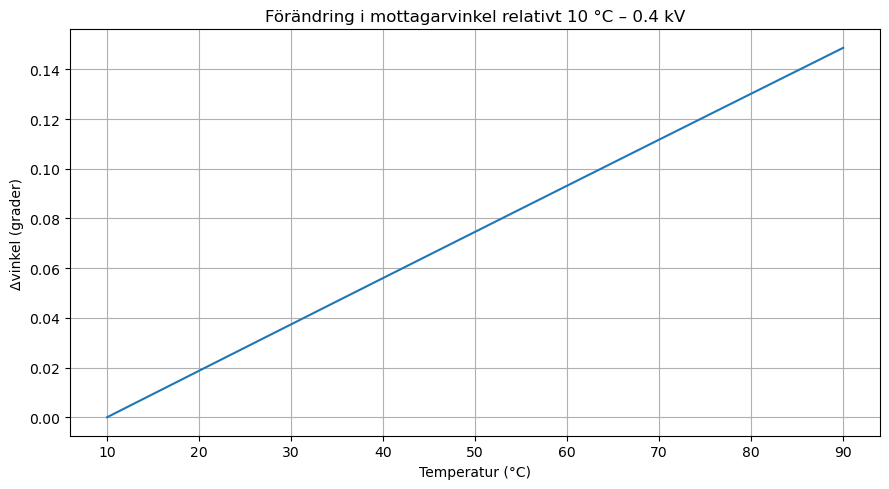

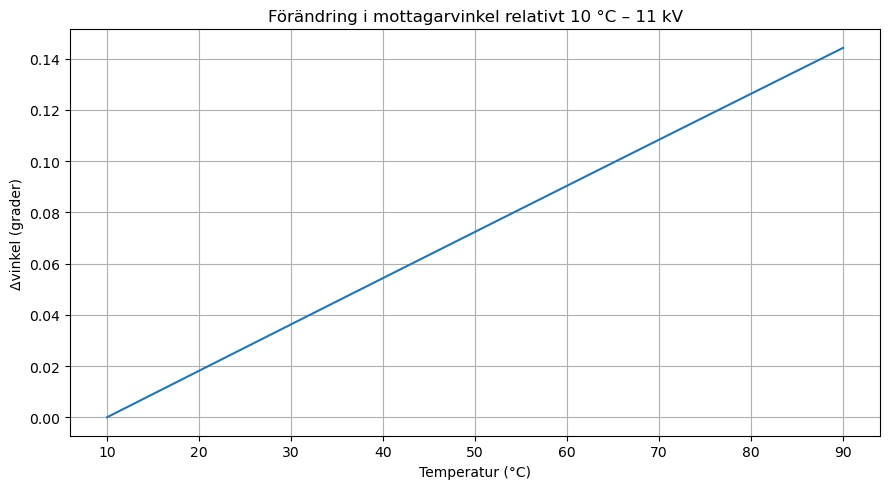

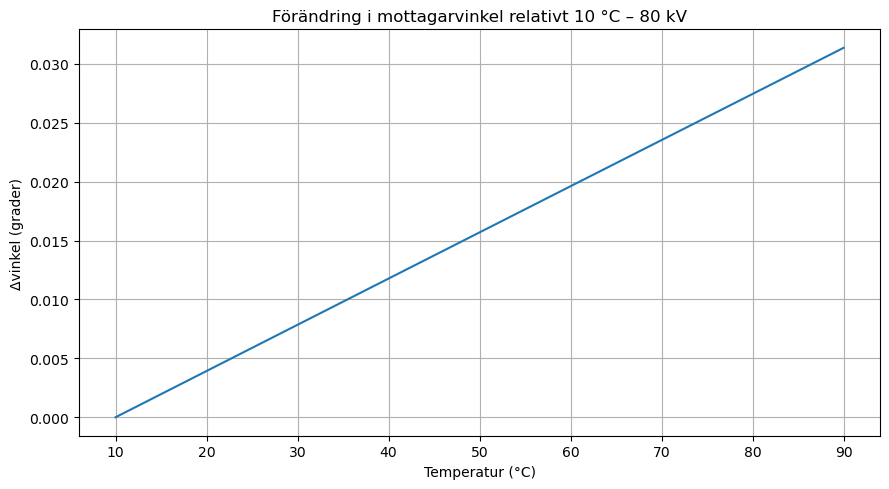

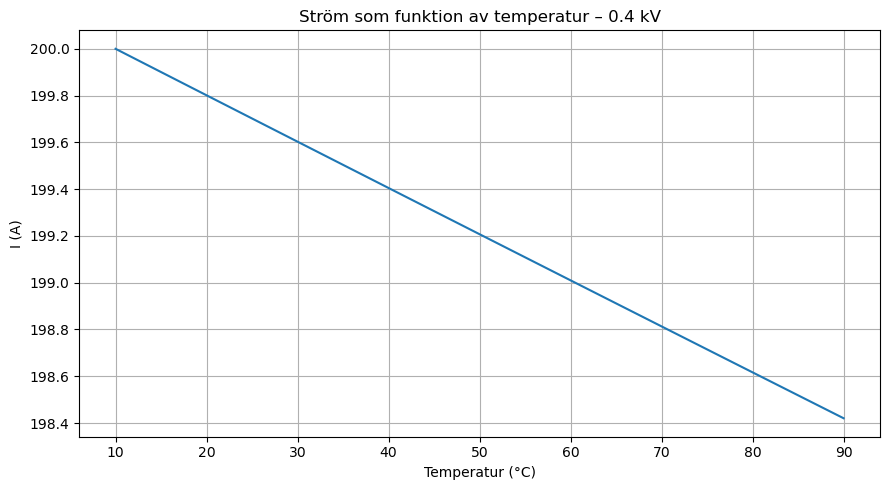

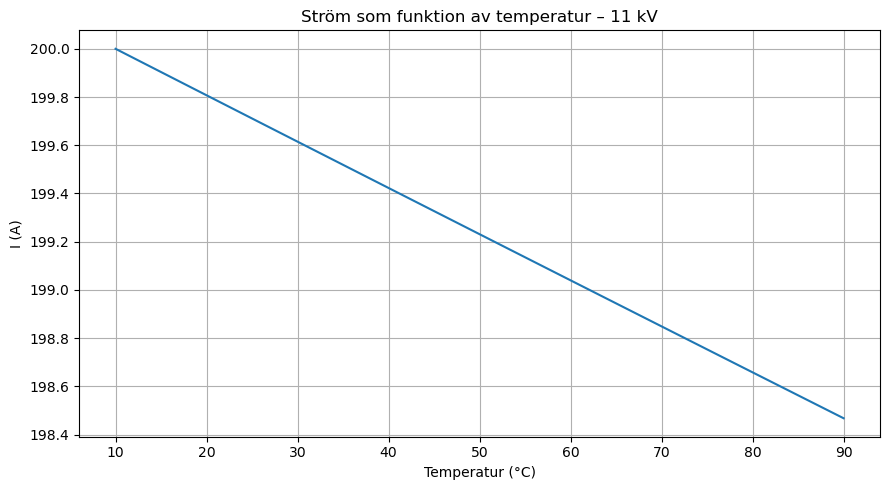

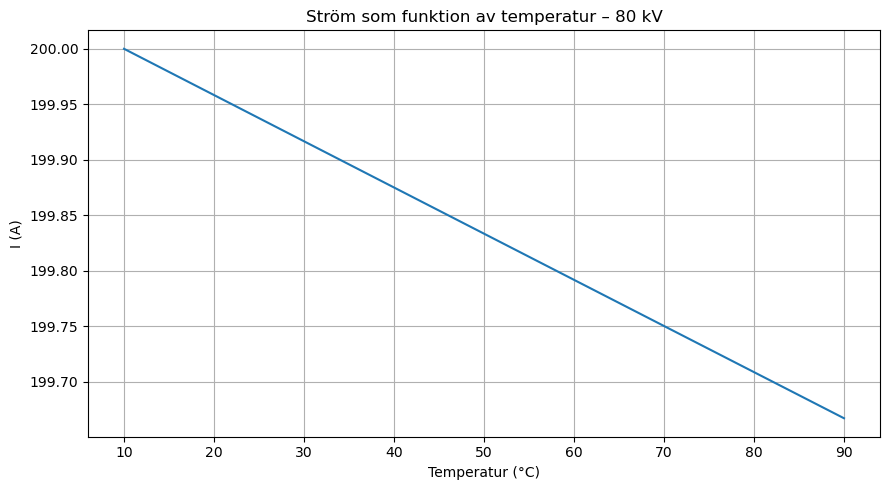

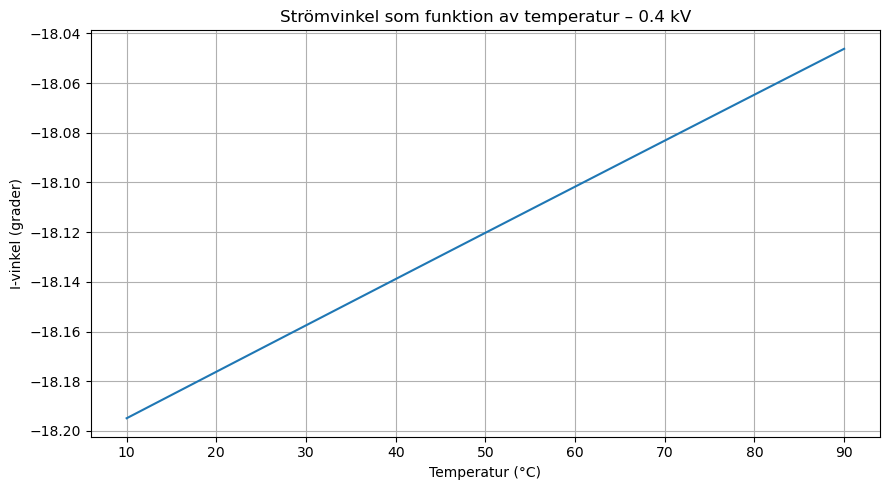

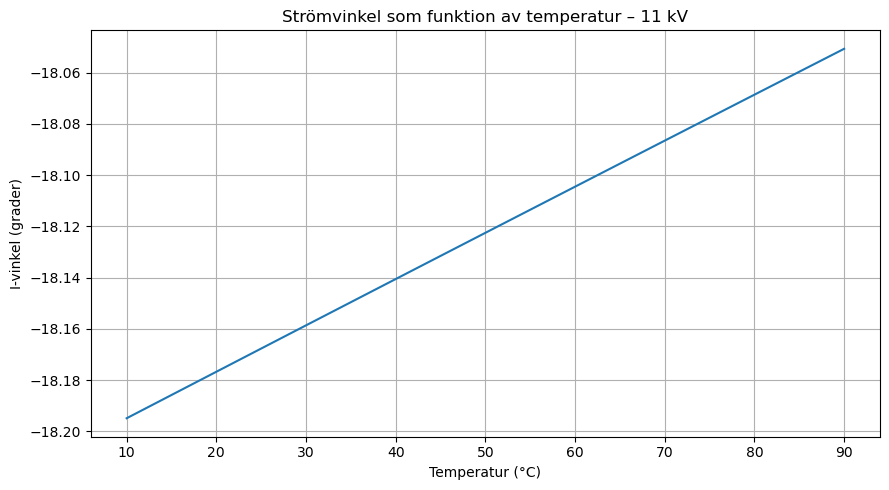

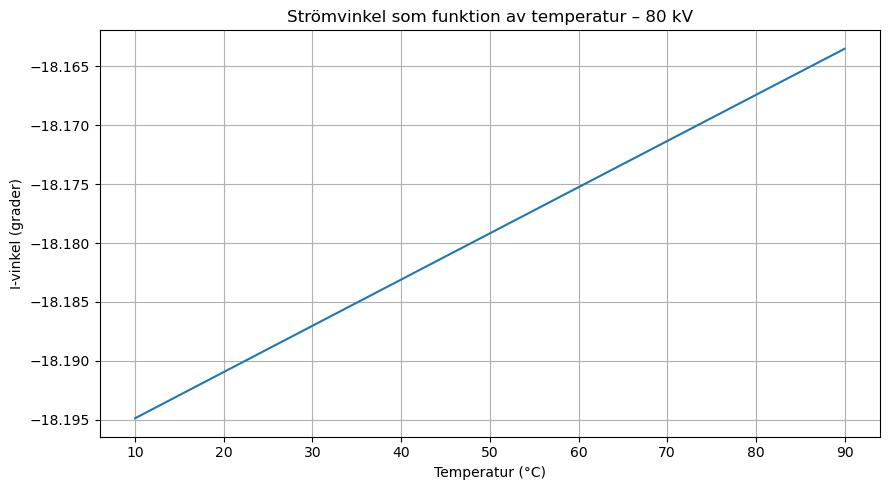

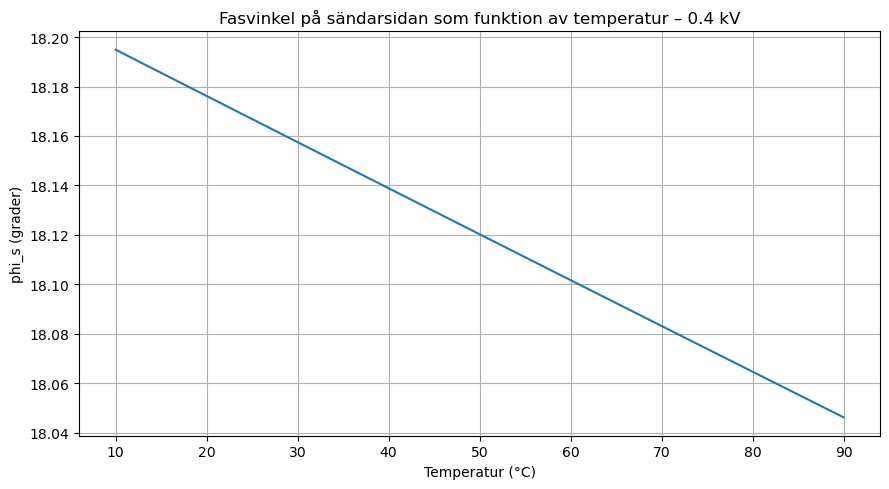

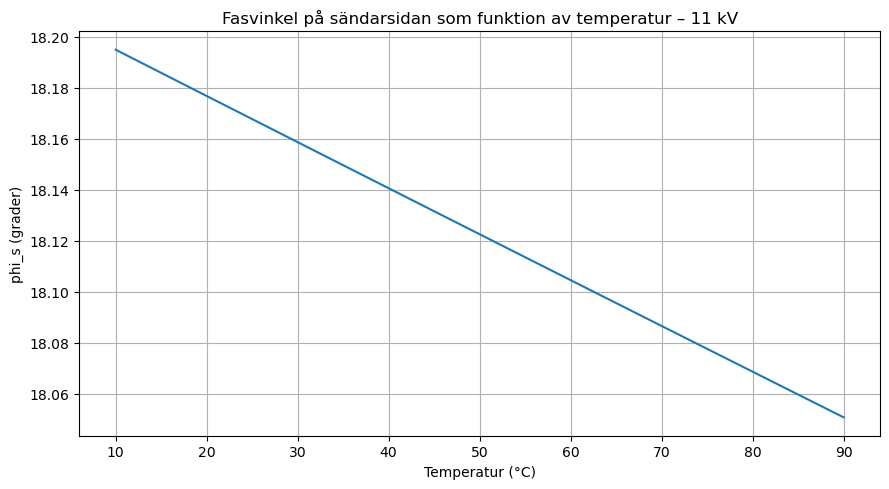

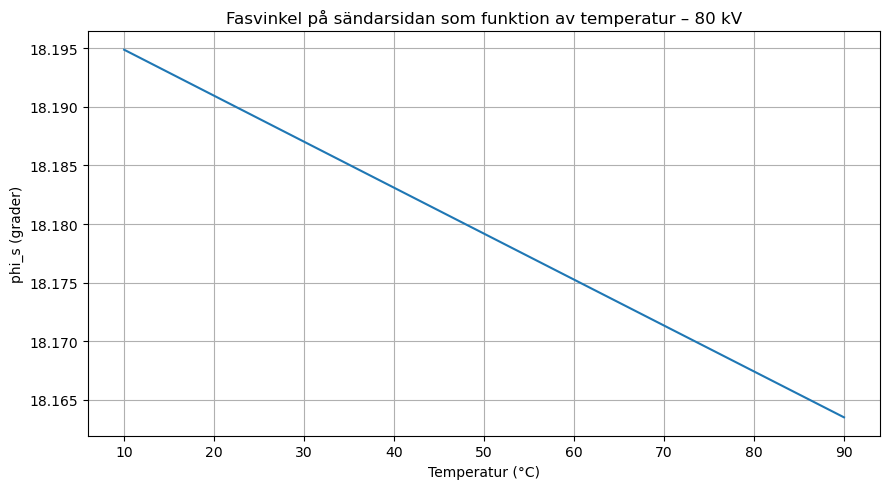

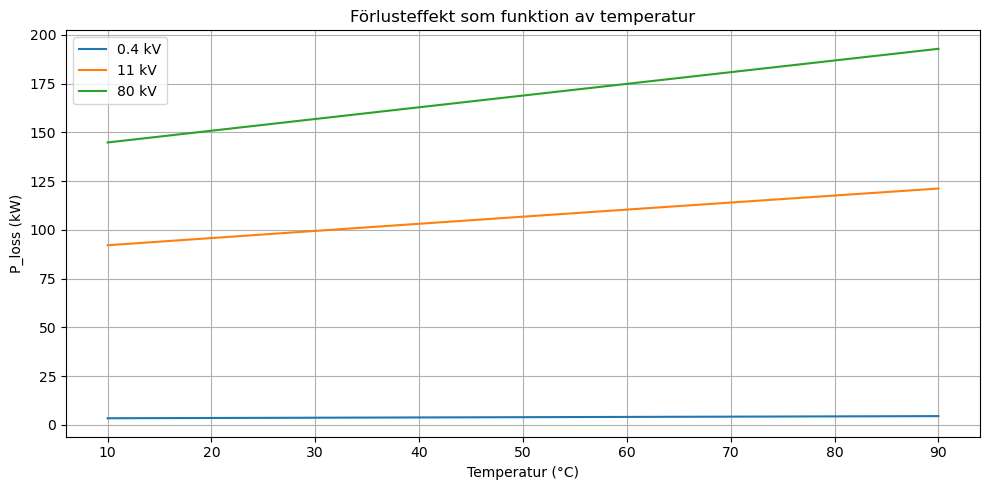

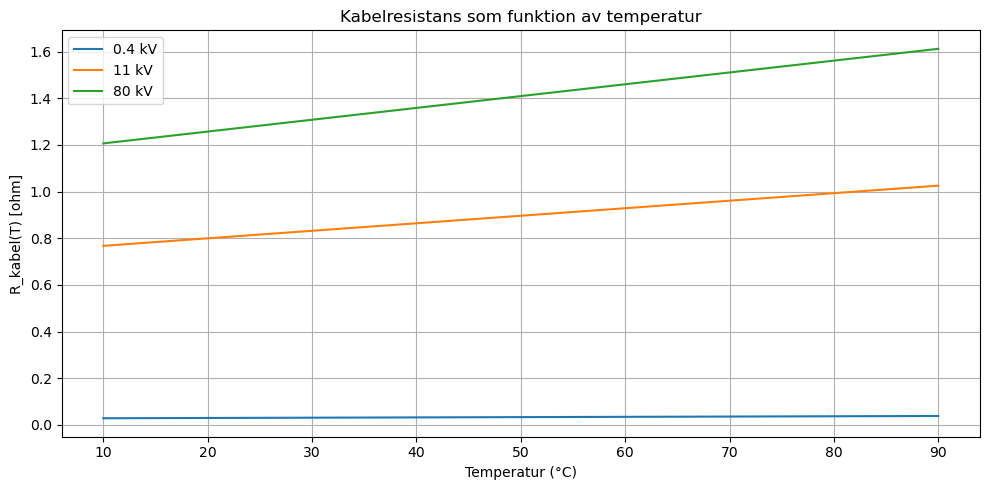

In [2]:
# ============================================================
# FRAMÅTRIKTAD LÄNKMODELL MED FAST LAST
# 10-90 grader
#
# Syfte:
#   Visa hur mottagarspänning, fasvinkel, ström och förlusteffekt
#   ändras när kabelns resistans ändras med temperaturen.
#
# Modell:
#   Vs = I * (Z_kabel(T) + Z_load)
#   Vr = I * Z_load
#   I(T) = Vs / (Z_kabel(T) + Z_load)
#
# Antaganden:
#   - balanserad trefas
#   - fast lastimpedans Z_load
#   - kabelreaktans X konstant
#   - kabelresistans R(T) temperaturberoende
# ============================================================

import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def safe_folder_name(name):
    return re.sub(r'[<>:"/\\|?*]', '_', name).strip().rstrip(".")

def polar(mag, ang_deg):
    return mag * np.exp(1j * np.deg2rad(ang_deg))

def angle_deg(z):
    return np.rad2deg(np.angle(z))

# ============================================================
# PARAMETRAR
# ============================================================

alpha = 0.00403
T_min = 10
T_max = 90

# ============================================================
# FAST LASTMODELL
# ============================================================

def run_case_fixed_load(label, U_LL_s, I_A_10, cosphi_10, R20_cable, X_cable, T_min=10, T_max=90):
    """
    Modell:
        Vs = I*(Z_cable(T) + Z_load)
        Vr = I*Z_load
        I(T) = Vs / (Z_cable(T) + Z_load)

    Steg:
    1) Välj driftfall vid 10 °C: U_LL,s, I, cosphi
    2) Beräkna kabelimpedans vid 10 °C
    3) Beräkna Z_load så att driftfallet stämmer vid 10 °C
    4) Håll Z_load konstant när kabelns R(T) ändras
    """

    # Sändarsidan som referens
    Vs = polar(U_LL_s / np.sqrt(3), 0.0)

    # Effektfaktorvinkel vid 10 °C
    phi10_deg = np.degrees(np.arccos(cosphi_10))

    # Ström vid 10 °C
    I10 = polar(I_A_10, -phi10_deg)

    # Kabel vid 10 °C
    R10 = R20_cable * (1 + alpha * (10 - 20.0))
    Zc10 = R10 + 1j * X_cable

    # Mottagarspänning vid 10 °C
    Vr10 = Vs - Zc10 * I10

    # Fast lastimpedans som gör att driftfallet stämmer vid 10 °C
    Zload = Vr10 / I10

    rows = []
    for T in range(T_min, T_max + 1):
        Rc = R20_cable * (1 + alpha * (T - 20.0))
        Zc = Rc + 1j * X_cable

        # Exakt lösning
        I = Vs / (Zc + Zload)
        Vr = I * Zload

        # Sändar- och mottagareffekt
        Ss = 3 * Vs * np.conj(I)
        Sr = 3 * Vr * np.conj(I)

        Ps = np.real(Ss)
        Qs = np.imag(Ss)
        Pr = np.real(Sr)
        Qr = np.imag(Sr)

        # Trefasförlust
        P_loss = Ps - Pr

        # Lokal fasvinkel på sändarsidan
        phi_s_deg = angle_deg(Vs) - angle_deg(I)

        # Lokal fasvinkel på mottagarsidan
        phi_r_deg = angle_deg(Vr) - angle_deg(I)

        rows.append({
            "Exempel": label,
            "T_C": T,
            "U_LL_s_V": U_LL_s,
            "I_A_exact": abs(I),
            "I_ang_deg_exact": angle_deg(I),
            "phi_s_deg_exact": phi_s_deg,
            "phi_r_deg_exact": phi_r_deg,
            "cosphi_s_exact": np.cos(np.deg2rad(phi_s_deg)),
            "cosphi_r_exact": np.cos(np.deg2rad(phi_r_deg)),
            "R_cable_Ohm": Rc,
            "X_cable_Ohm": X_cable,
            "R_load_Ohm": np.real(Zload),
            "X_load_Ohm": np.imag(Zload),
            "Vr_LL_exact_V": abs(Vr) * np.sqrt(3),
            "Vr_ang_exact_deg": angle_deg(Vr),
            "P_send_W": Ps,
            "Q_send_var": Qs,
            "P_rec_W": Pr,
            "Q_rec_var": Qr,
            "P_loss_W": P_loss,
        })

    df = pd.DataFrame(rows)

    row10 = df[df["T_C"] == 10].iloc[0]
    row90 = df[df["T_C"] == 90].iloc[0]

    print(f"\n=== {label} ===")
    print(f"U_LL,s = {U_LL_s:.1f} V")
    print(f"I(10°C) = {I_A_10:.1f} A")
    print(f"cos(phi)(10°C) = {cosphi_10:.3f}")
    print(f"R20_kabel = {R20_cable:.6f} ohm")
    print(f"X_kabel = {X_cable:.6f} ohm")
    print(f"Beräknad fast last: Z_load = {np.real(Zload):.6f} + j{np.imag(Zload):.6f} ohm")

    print("\nVid 10 °C:")
    print(f"  R_kabel(10)      = {row10['R_cable_Ohm']:.6f} ohm")
    print(f"  I_exact(10)      = {row10['I_A_exact']:.6f} A")
    print(f"  Vr_LL_exact(10)  = {row10['Vr_LL_exact_V']:.2f} V")
    print(f"  Vr_ang_exact(10) = {row10['Vr_ang_exact_deg']:.6f} deg")
    print(f"  P_loss(10)       = {row10['P_loss_W']:.2f} W")

    print("\nVid 90 °C:")
    print(f"  R_kabel(90)      = {row90['R_cable_Ohm']:.6f} ohm")
    print(f"  I_exact(90)      = {row90['I_A_exact']:.6f} A")
    print(f"  Vr_LL_exact(90)  = {row90['Vr_LL_exact_V']:.2f} V")
    print(f"  Vr_ang_exact(90) = {row90['Vr_ang_exact_deg']:.6f} deg")
    print(f"  P_loss(90)       = {row90['P_loss_W']:.2f} W")

    print("\nSkillnad 10 -> 90 °C:")
    print(f"  Delta I          = {row90['I_A_exact'] - row10['I_A_exact']:.6f} A")
    print(f"  Delta Vr_LL      = {row90['Vr_LL_exact_V'] - row10['Vr_LL_exact_V']:.2f} V")
    print(f"  Delta Vr_ang     = {row90['Vr_ang_exact_deg'] - row10['Vr_ang_exact_deg']:.6f} deg")
    print(f"  Delta P_loss     = {row90['P_loss_W'] - row10['P_loss_W']:.2f} W")

    return df, Zload

# ============================================================
# TRE EXEMPEL
# 0.4 kV och 11 kV är illustrativa
# 80 kV är Bohus-likt
# ============================================================

df_04, Zload_04 = run_case_fixed_load(
    label="0.4 kV",
    U_LL_s=400.0,
    I_A_10=200.0,
    cosphi_10=0.95,
    R20_cable=0.030,
    X_cable=0.008,
    T_min=T_min,
    T_max=T_max
)

df_11, Zload_11 = run_case_fixed_load(
    label="11 kV",
    U_LL_s=11000.0,
    I_A_10=200.0,
    cosphi_10=0.95,
    R20_cable=0.800,
    X_cable=0.450,
    T_min=T_min,
    T_max=T_max
)

df_80, Zload_80 = run_case_fixed_load(
    label="80 kV",
    U_LL_s=80000.0,
    I_A_10=200.0,
    cosphi_10=0.95,
    R20_cable=1.2575,
    X_cable=6.555,
    T_min=T_min,
    T_max=T_max
)

# ============================================================
# SAMMANFATTNING
# ============================================================

def pick_summary_fixed(df, label):
    row10 = df[df["T_C"] == 10].iloc[0]
    row90 = df[df["T_C"] == 90].iloc[0]

    delta_T_total = T_max - T_min
    n_5C_steps = delta_T_total / 5.0

    delta_v = row90["Vr_LL_exact_V"] - row10["Vr_LL_exact_V"]
    delta_ang = row90["Vr_ang_exact_deg"] - row10["Vr_ang_exact_deg"]
    delta_i = row90["I_A_exact"] - row10["I_A_exact"]
    delta_i_ang = row90["I_ang_deg_exact"] - row10["I_ang_deg_exact"]
    delta_phi_s = row90["phi_s_deg_exact"] - row10["phi_s_deg_exact"]
    delta_phi_r = row90["phi_r_deg_exact"] - row10["phi_r_deg_exact"]
    delta_p = row90["P_loss_W"] - row10["P_loss_W"]

    return {
        "Exempel": label,
        "R_10_Ohm": row10["R_cable_Ohm"],
        "R_90_Ohm": row90["R_cable_Ohm"],
        "Delta_R_per_5C_Ohm": (row90["R_cable_Ohm"] - row10["R_cable_Ohm"]) / n_5C_steps,

        "Vr_10_V": row10["Vr_LL_exact_V"],
        "Vr_90_V": row90["Vr_LL_exact_V"],
        "Delta_Vr_V": delta_v,
        "Delta_Vr_pct": 100.0 * delta_v / row10["Vr_LL_exact_V"],
        "Delta_Vr_abs_pct": 100.0 * abs(delta_v) / row10["Vr_LL_exact_V"],
        "Delta_Vr_per_5C_V": delta_v / n_5C_steps,
        "Delta_Vr_abs_per_5C_V": abs(delta_v) / n_5C_steps,

        "Vr_ang_10_deg": row10["Vr_ang_exact_deg"],
        "Vr_ang_90_deg": row90["Vr_ang_exact_deg"],
        "Delta_Vr_ang_deg": delta_ang,
        "Delta_Vr_ang_per_5C_deg": delta_ang / n_5C_steps,

        "I_10_A": row10["I_A_exact"],
        "I_90_A": row90["I_A_exact"],
        "Delta_I_A": delta_i,
        "Delta_I_per_5C_A": delta_i / n_5C_steps,

        "I_ang_10_deg": row10["I_ang_deg_exact"],
        "I_ang_90_deg": row90["I_ang_deg_exact"],
        "Delta_I_ang_deg": delta_i_ang,
        "Delta_I_ang_per_5C_deg": delta_i_ang / n_5C_steps,

        "phi_s_10_deg": row10["phi_s_deg_exact"],
        "phi_s_90_deg": row90["phi_s_deg_exact"],
        "Delta_phi_s_deg": delta_phi_s,
        "Delta_phi_s_per_5C_deg": delta_phi_s / n_5C_steps,

        "phi_r_10_deg": row10["phi_r_deg_exact"],
        "phi_r_90_deg": row90["phi_r_deg_exact"],
        "Delta_phi_r_deg": delta_phi_r,
        "Delta_phi_r_per_5C_deg": delta_phi_r / n_5C_steps,

        "P_loss_10_W": row10["P_loss_W"],
        "P_loss_90_W": row90["P_loss_W"],
        "Delta_P_loss_W": delta_p,
        "Delta_P_loss_per_5C_W": delta_p / n_5C_steps,
        "Delta_P_loss_per_5C_kW": delta_p / n_5C_steps / 1000.0,
    }

summary = pd.DataFrame([
    pick_summary_fixed(df_04, "0.4 kV"),
    pick_summary_fixed(df_11, "11 kV"),
    pick_summary_fixed(df_80, "80 kV"),
])

print("\n=== SAMMANFATTNING ===")
print(summary.round(6))

# ============================================================
# SPARA
# ============================================================

VERSION = "10-90_grader_fast_last"
output_dir = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data") / safe_folder_name(VERSION)
output_dir.mkdir(parents=True, exist_ok=True)

summary.to_excel(output_dir / "summary_fast_last.xlsx", index=False)
summary.to_csv(output_dir / "summary_fast_last.csv", index=False)

df_04.to_excel(output_dir / "case_fixed_load_0_4kV.xlsx", index=False)
df_11.to_excel(output_dir / "case_fixed_load_11kV.xlsx", index=False)
df_80.to_excel(output_dir / "case_fixed_load_80kV.xlsx", index=False)

print("\nSparat till:", output_dir.resolve())

# ============================================================
# FIGURER
# ============================================================

cases = [
    ("0.4 kV", df_04, "0_4kV"),
    ("11 kV", df_11, "11kV"),
    ("80 kV", df_80, "80kV"),
]

# 1. Exakt mottagarspänning
for label, df_case, tag in cases:
    plt.figure(figsize=(9, 5))
    plt.plot(df_case["T_C"], df_case["Vr_LL_exact_V"])
    plt.title(f"Mottagarspänning som funktion av temperatur – {label}")
    plt.xlabel("Temperatur (°C)")
    plt.ylabel("U_LL,r (V)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"Vr_vs_T_{tag}.png", dpi=200)
    plt.show()

# 2. Förändring i mottagarspänning relativt 10 °C (V)
for label, df_case, tag in cases:
    Vr0 = df_case.loc[df_case["T_C"] == 10, "Vr_LL_exact_V"].iloc[0]
    delta_V = df_case["Vr_LL_exact_V"] - Vr0

    plt.figure(figsize=(9, 5))
    plt.plot(df_case["T_C"], delta_V)
    plt.title(f"Förändring i mottagarspänning relativt 10 °C – {label}")
    plt.xlabel("Temperatur (°C)")
    plt.ylabel("ΔU_LL,r (V)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"Delta_Vr_vs_T_{tag}.png", dpi=200)
    plt.show()

# 3. Förändring i mottagarspänning relativt 10 °C (%)
for label, df_case, tag in cases:
    Vr0 = df_case.loc[df_case["T_C"] == 10, "Vr_LL_exact_V"].iloc[0]
    delta_V_pct = 100.0 * (df_case["Vr_LL_exact_V"] - Vr0) / Vr0

    plt.figure(figsize=(9, 5))
    plt.plot(df_case["T_C"], delta_V_pct)
    plt.title(f"Förändring i mottagarspänning relativt 10 °C – {label}")
    plt.xlabel("Temperatur (°C)")
    plt.ylabel("ΔU_LL,r (%)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"Delta_Vr_pct_vs_T_{tag}.png", dpi=200)
    plt.show()

# 4. Mottagarvinkel
for label, df_case, tag in cases:
    plt.figure(figsize=(9, 5))
    plt.plot(df_case["T_C"], df_case["Vr_ang_exact_deg"])
    plt.title(f"Mottagarvinkel som funktion av temperatur – {label}")
    plt.xlabel("Temperatur (°C)")
    plt.ylabel("Vinkel (grader)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"Vr_angle_vs_T_{tag}.png", dpi=200)
    plt.show()

# 5. Förändring i mottagarvinkel relativt 10 °C
for label, df_case, tag in cases:
    ang0 = df_case.loc[df_case["T_C"] == 10, "Vr_ang_exact_deg"].iloc[0]
    delta_ang = df_case["Vr_ang_exact_deg"] - ang0

    plt.figure(figsize=(9, 5))
    plt.plot(df_case["T_C"], delta_ang)
    plt.title(f"Förändring i mottagarvinkel relativt 10 °C – {label}")
    plt.xlabel("Temperatur (°C)")
    plt.ylabel("Δvinkel (grader)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"Delta_Vr_angle_vs_T_{tag}.png", dpi=200)
    plt.show()

# 6. Ström
for label, df_case, tag in cases:
    plt.figure(figsize=(9, 5))
    plt.plot(df_case["T_C"], df_case["I_A_exact"])
    plt.title(f"Ström som funktion av temperatur – {label}")
    plt.xlabel("Temperatur (°C)")
    plt.ylabel("I (A)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"I_vs_T_{tag}.png", dpi=200)
    plt.show()

# 7. Strömvinkel
for label, df_case, tag in cases:
    plt.figure(figsize=(9, 5))
    plt.plot(df_case["T_C"], df_case["I_ang_deg_exact"])
    plt.title(f"Strömvinkel som funktion av temperatur – {label}")
    plt.xlabel("Temperatur (°C)")
    plt.ylabel("I-vinkel (grader)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"I_angle_vs_T_{tag}.png", dpi=200)
    plt.show()

# 8. Lokal fasvinkel phi_s
for label, df_case, tag in cases:
    plt.figure(figsize=(9, 5))
    plt.plot(df_case["T_C"], df_case["phi_s_deg_exact"])
    plt.title(f"Fasvinkel på sändarsidan som funktion av temperatur – {label}")
    plt.xlabel("Temperatur (°C)")
    plt.ylabel("phi_s (grader)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"phi_s_vs_T_{tag}.png", dpi=200)
    plt.show()

# 9. Förlusteffekt
plt.figure(figsize=(10, 5))
plt.plot(df_04["T_C"], df_04["P_loss_W"]/1000, label="0.4 kV")
plt.plot(df_11["T_C"], df_11["P_loss_W"]/1000, label="11 kV")
plt.plot(df_80["T_C"], df_80["P_loss_W"]/1000, label="80 kV")
plt.title("Förlusteffekt som funktion av temperatur")
plt.xlabel("Temperatur (°C)")
plt.ylabel("P_loss (kW)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "Ploss_vs_T_all.png", dpi=200)
plt.show()

# 10. Resistans
plt.figure(figsize=(10, 5))
plt.plot(df_04["T_C"], df_04["R_cable_Ohm"], label="0.4 kV")
plt.plot(df_11["T_C"], df_11["R_cable_Ohm"], label="11 kV")
plt.plot(df_80["T_C"], df_80["R_cable_Ohm"], label="80 kV")
plt.title("Kabelresistans som funktion av temperatur")
plt.xlabel("Temperatur (°C)")
plt.ylabel("R_kabel(T) [ohm]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "R_vs_T_all.png", dpi=200)
plt.show()

Sparar till: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\10-90_grader_fast_last_current_axis


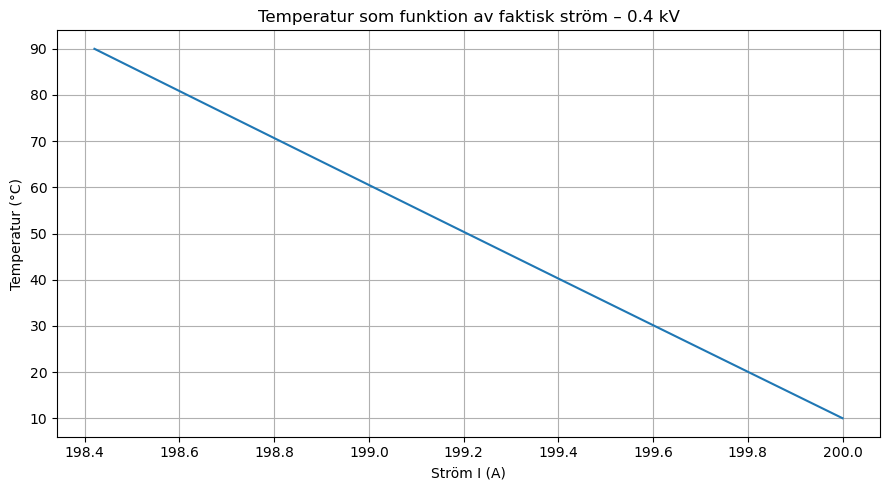

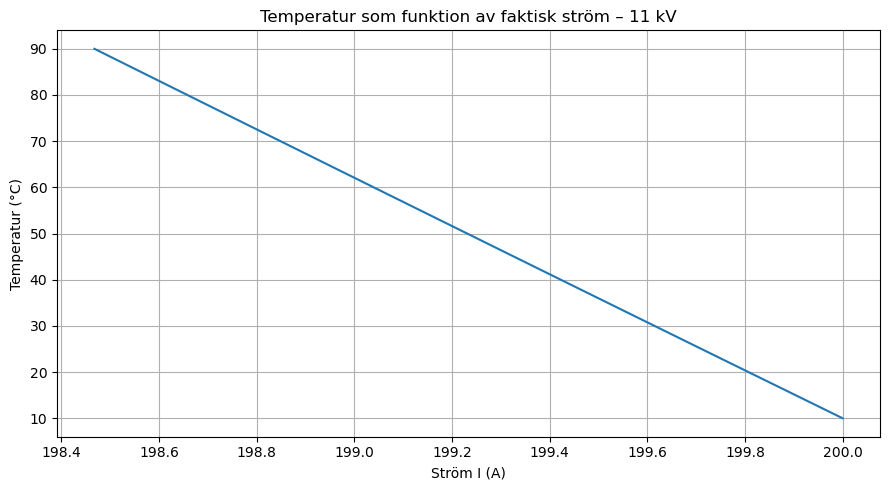

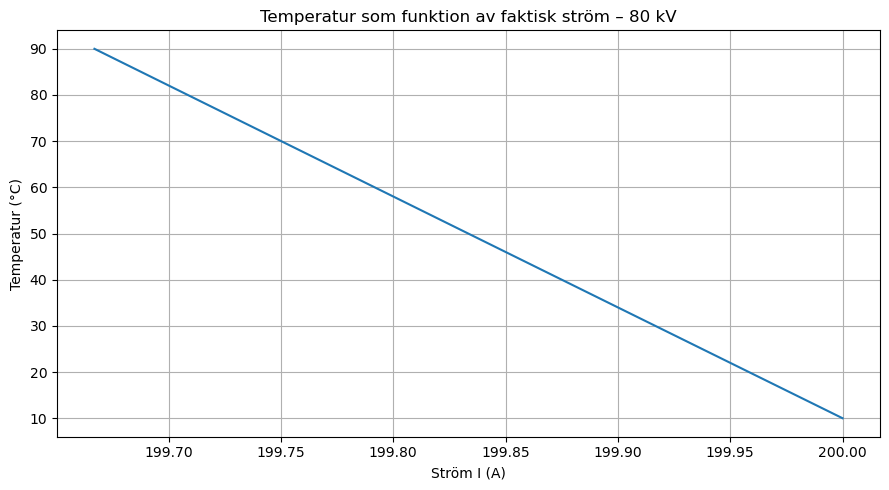

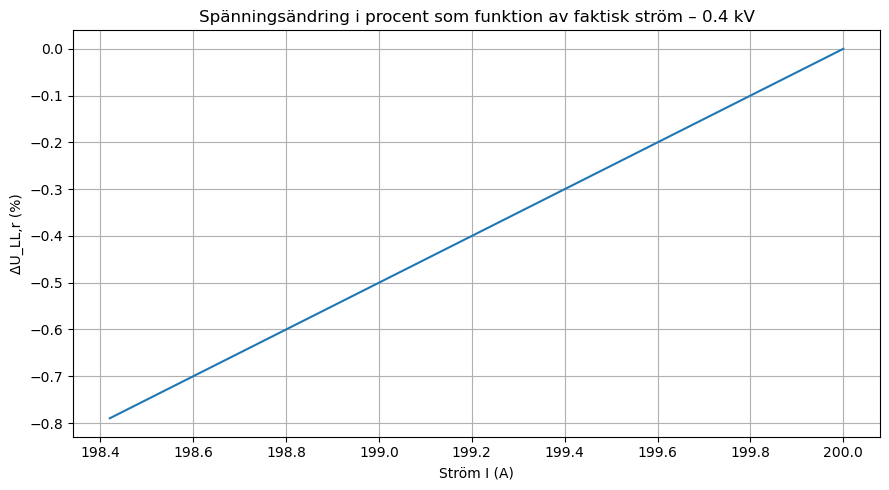

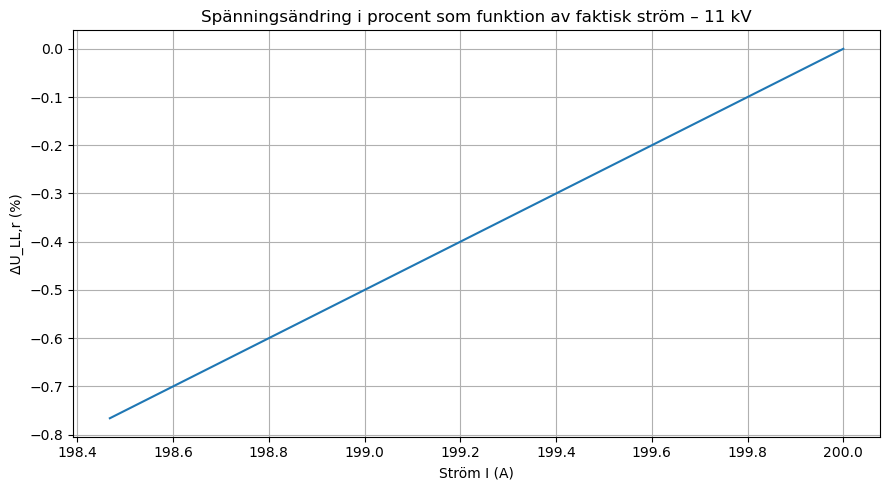

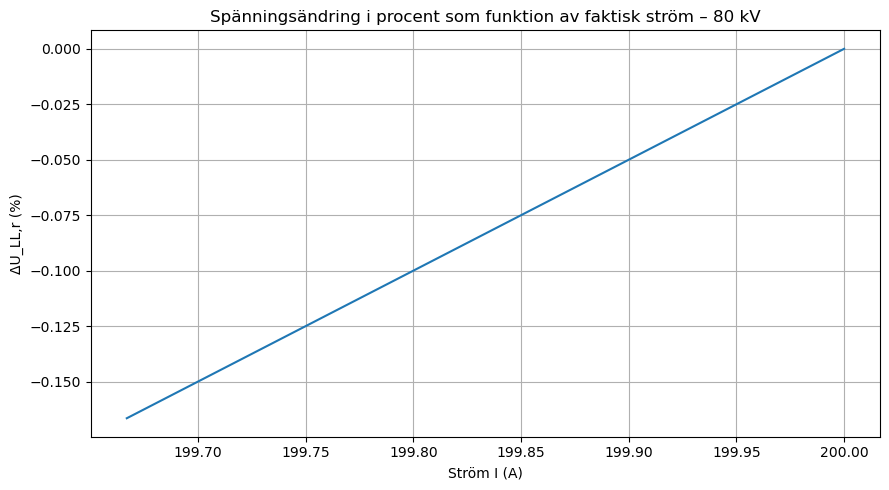

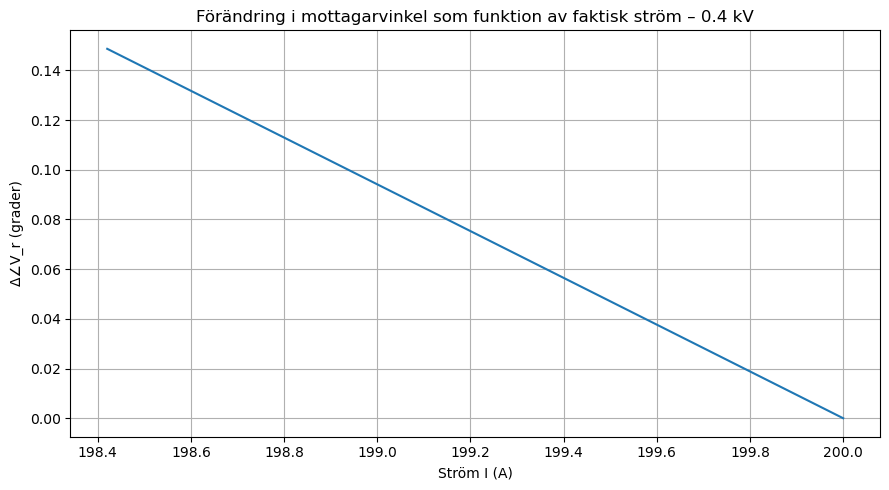

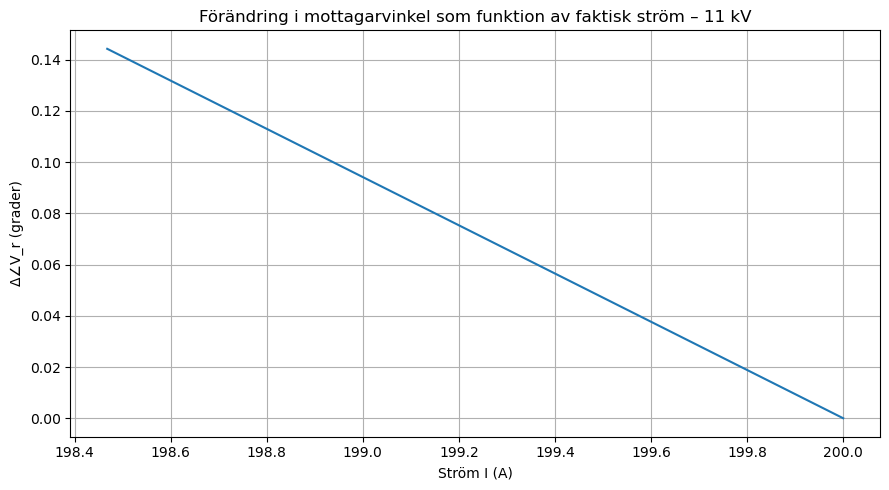

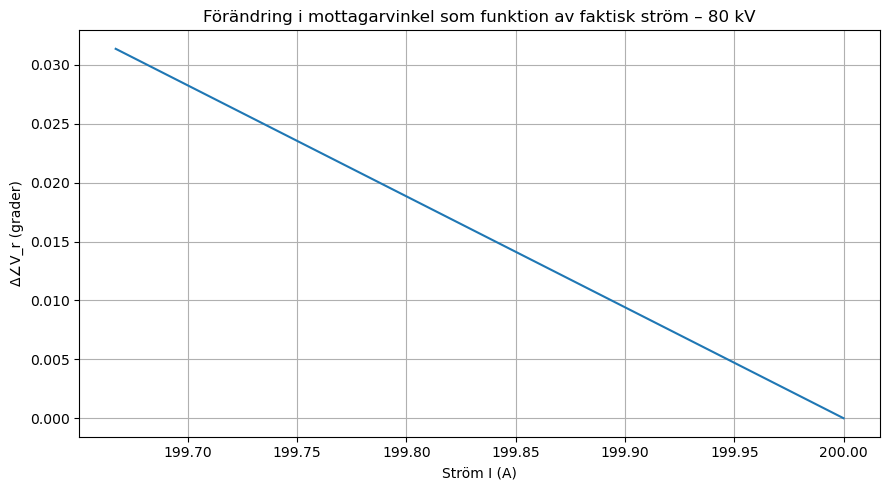

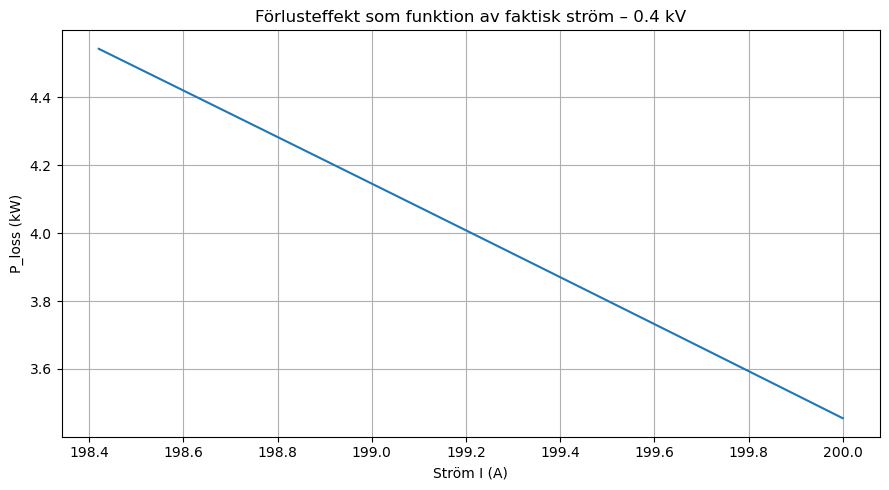

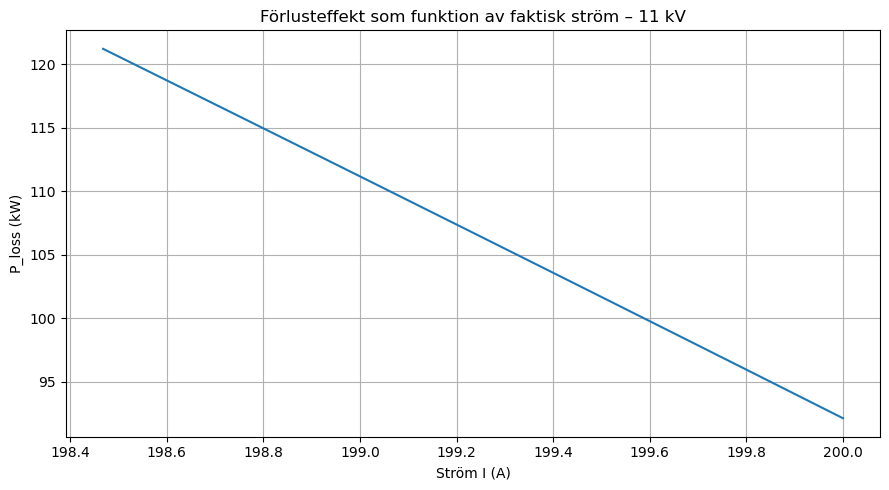

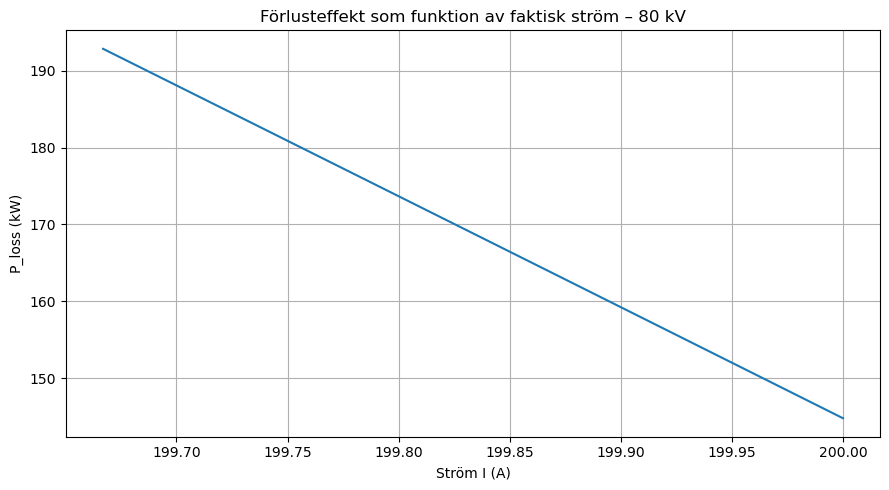

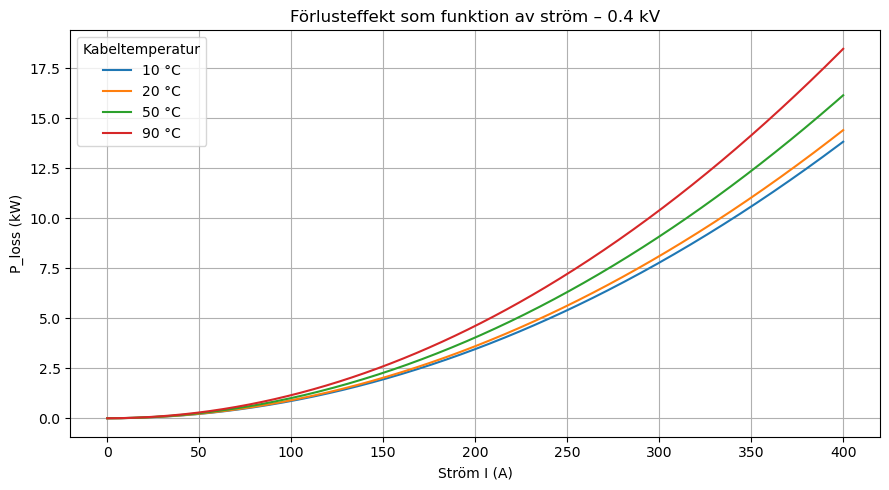

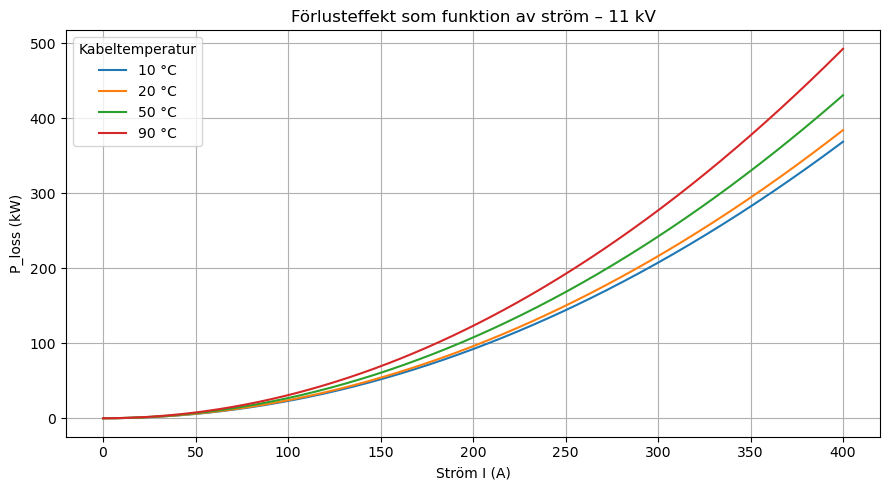

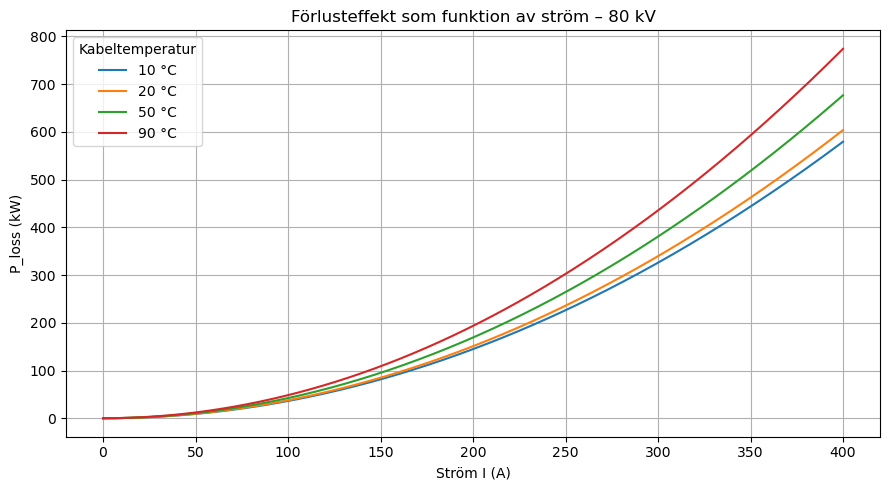

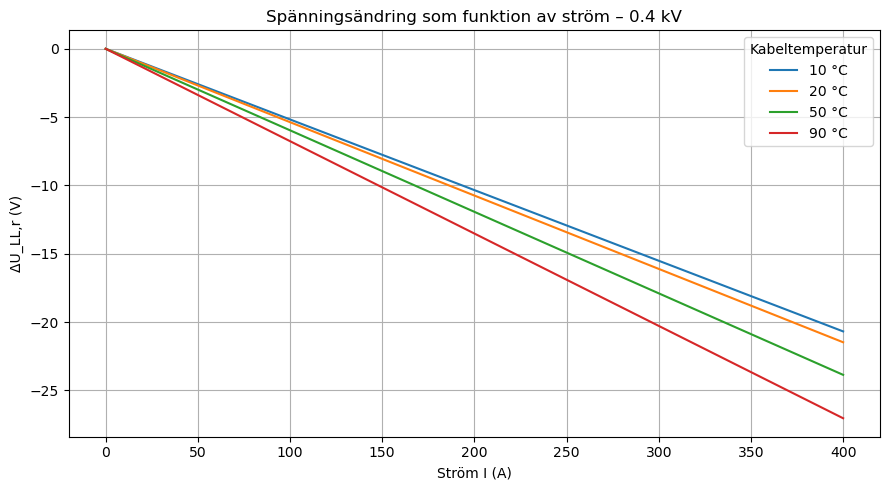

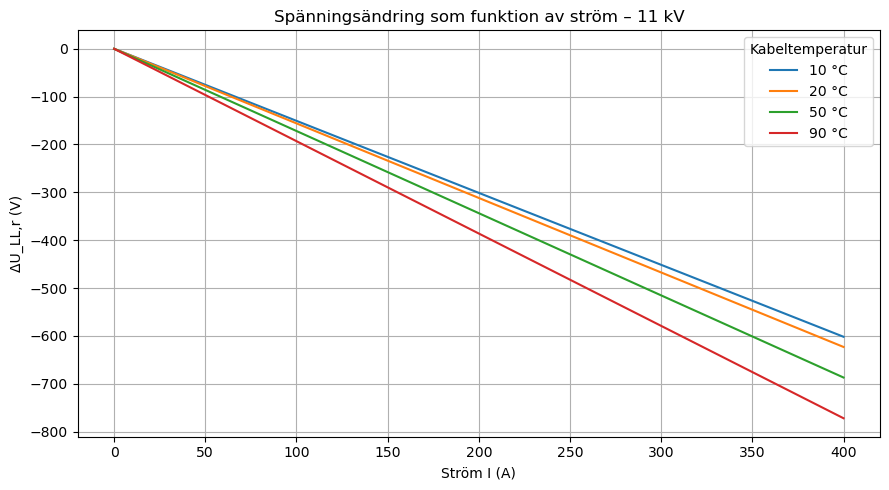

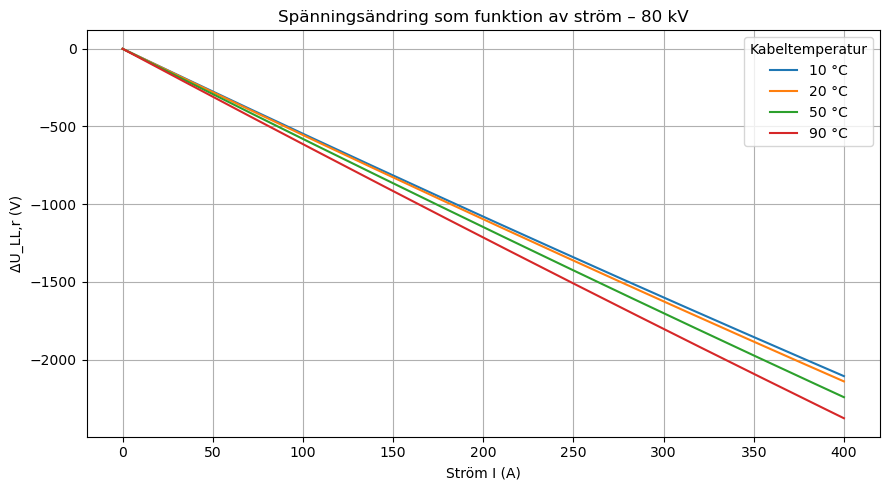

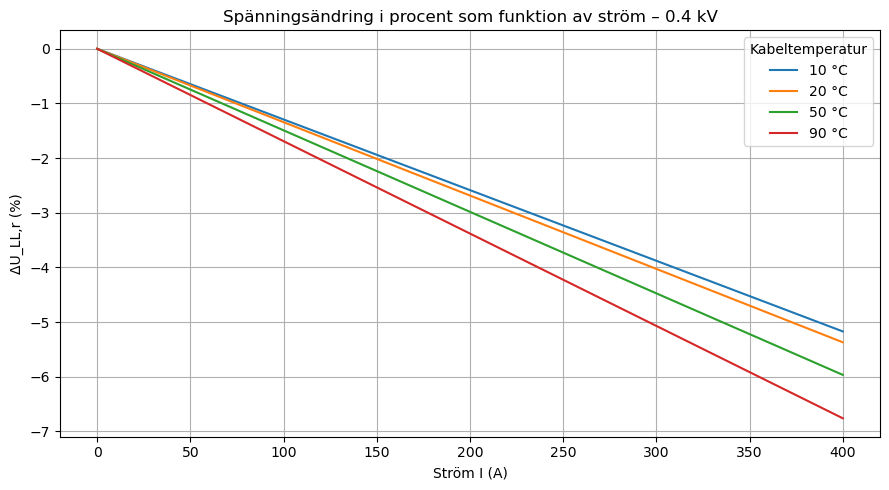

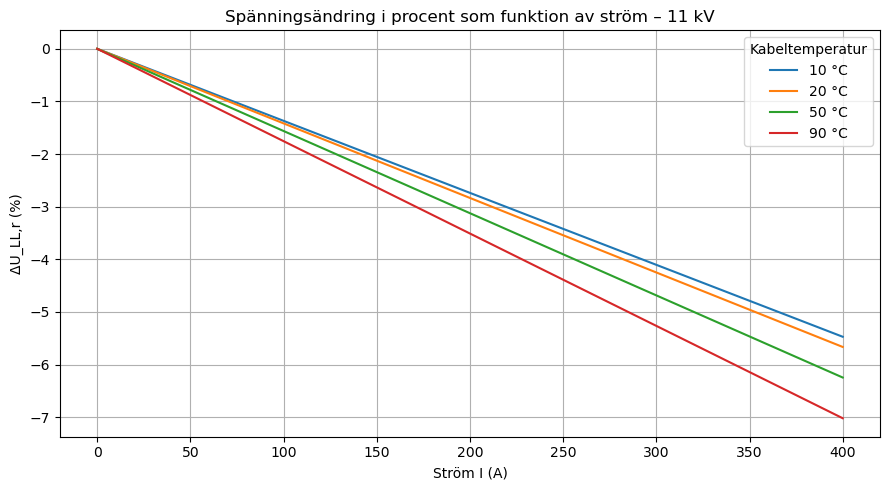

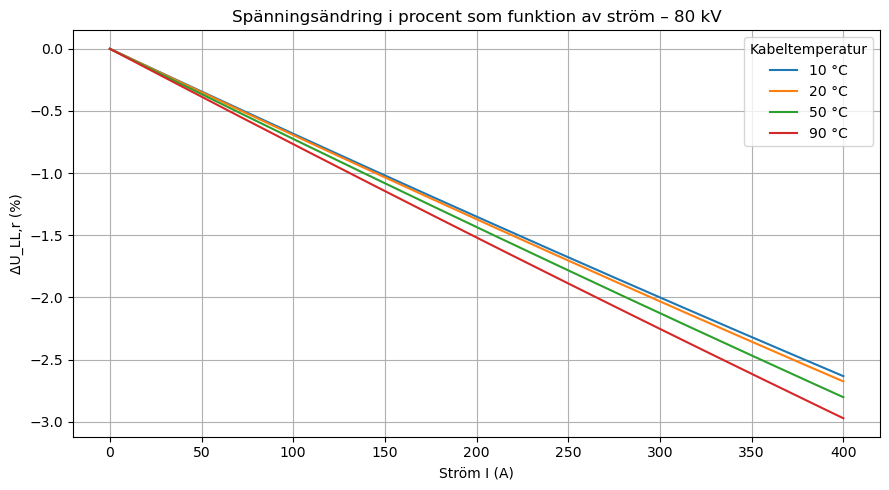

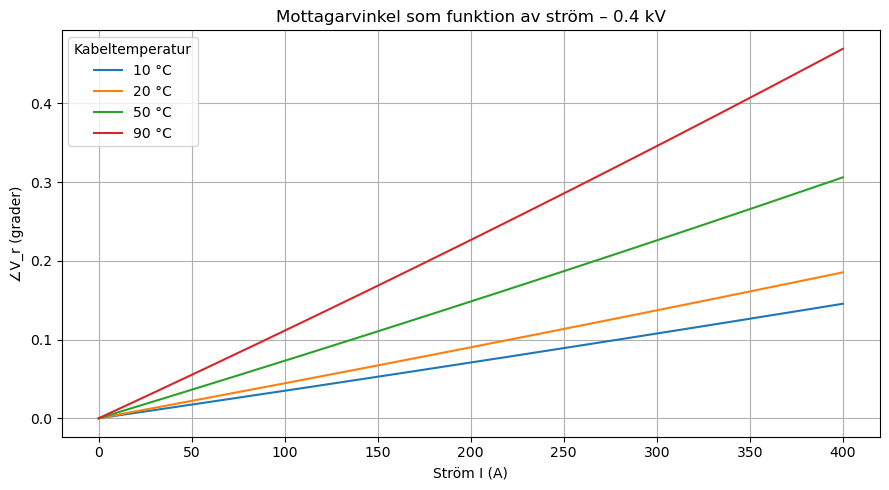

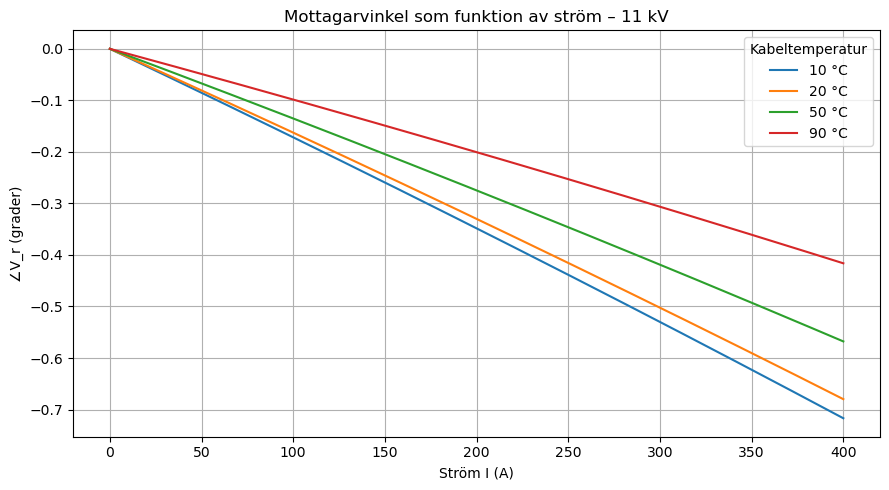

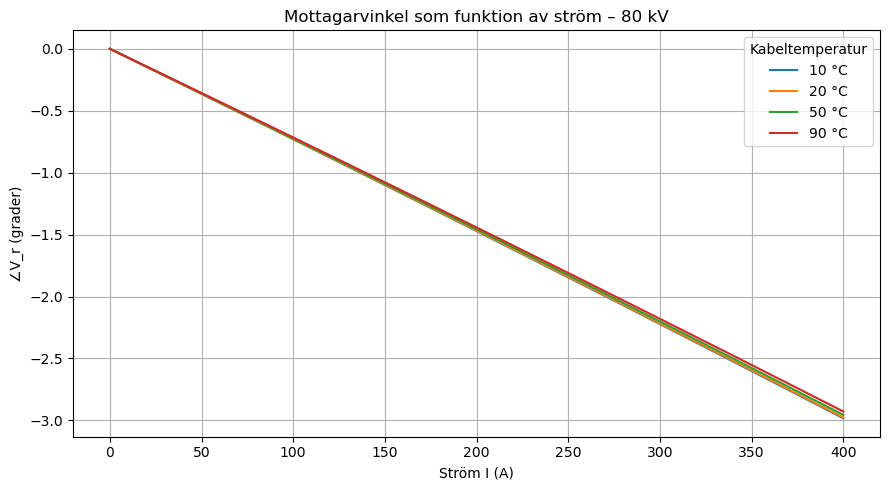


=== SAMMANFATTNING STRÖMSVEEP VID 200 A OCH 400 A ===
   Exempel  T_C  I_A  P_loss_kW   Delta_Vr_V  Delta_Vr_pct  Vr_ang_deg
0   0.4 kV   10  200    3.45492   -10.339855     -2.584964    0.070801
1   0.4 kV   10  400   13.81968   -20.679083     -5.169771    0.145461
2   0.4 kV   20  200    3.60000   -10.737540     -2.684385    0.090122
3   0.4 kV   20  400   14.40000   -21.474063     -5.368516    0.185356
4   0.4 kV   50  200    4.03524   -11.930330     -2.982582    0.148322
5   0.4 kV   50  400   16.14096   -23.857894     -5.964473    0.306052
6   0.4 kV   90  200    4.61556   -13.520088     -3.380022    0.226482
7   0.4 kV   90  400   18.46224   -27.033700     -6.758425    0.469379
8    11 kV   10  200   92.13120  -301.139092     -2.737628   -0.348335
9    11 kV   10  400  368.52480  -601.859841     -5.471453   -0.716833
10   11 kV   20  200   96.00000  -311.769399     -2.834267   -0.329987
11   11 kV   20  400  384.00000  -623.162970     -5.665118   -0.679792
12   11 kV   50  200  

In [3]:
# ============================================================
# STRÖM PÅ X-AXELN
#
# Del A:
#   Plotta befintliga fast-load-resultat mot faktisk ström I(T)
#
# Del B:
#   Gör ett separat strömsvep för att visa I²-sambandet
#   i förlusteffekt och spänningsfall
#
# Kör denna EFTER senaste fast-load-koden.
# ============================================================

import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def safe_folder_name(name):
    return re.sub(r'[<>:"/\\|?*]', '_', name).strip().rstrip(".")

def polar(mag, ang_deg):
    return mag * np.exp(1j * np.deg2rad(ang_deg))

def angle_deg(z):
    return np.rad2deg(np.angle(z))

# ============================================================
# SPARA
# ============================================================

VERSION = "10-90_grader_fast_last_current_axis"

try:
    base_dir = output_dir.parent
except NameError:
    base_dir = Path(
        r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data"
    )

output_dir_I = base_dir / safe_folder_name(VERSION)
output_dir_I.mkdir(parents=True, exist_ok=True)

print("Sparar till:", output_dir_I.resolve())

# ============================================================
# DEL A:
# BEFINTLIG FAST-LOAD-MODELL MEN MED STRÖM PÅ X-AXELN
# ============================================================

cases_existing = [
    ("0.4 kV", df_04, "0_4kV"),
    ("11 kV", df_11, "11kV"),
    ("80 kV", df_80, "80kV"),
]

def add_relative_columns(df):
    """
    Lägger till förändringar relativt 10 °C.
    """
    df = df.copy()

    row10 = df[df["T_C"] == 10].iloc[0]

    df["Delta_Vr_V_rel_10C"] = df["Vr_LL_exact_V"] - row10["Vr_LL_exact_V"]
    df["Delta_Vr_pct_rel_10C"] = 100.0 * df["Delta_Vr_V_rel_10C"] / row10["Vr_LL_exact_V"]

    df["Delta_Vr_ang_deg_rel_10C"] = df["Vr_ang_exact_deg"] - row10["Vr_ang_exact_deg"]

    df["Delta_P_loss_kW_rel_10C"] = (df["P_loss_W"] - row10["P_loss_W"]) / 1000.0
    df["Delta_I_A_rel_10C"] = df["I_A_exact"] - row10["I_A_exact"]

    return df

df_04_I = add_relative_columns(df_04)
df_11_I = add_relative_columns(df_11)
df_80_I = add_relative_columns(df_80)

cases_I = [
    ("0.4 kV", df_04_I, "0_4kV"),
    ("11 kV", df_11_I, "11kV"),
    ("80 kV", df_80_I, "80kV"),
]

# Spara befintliga data med extra kolumner
df_04_I.to_excel(output_dir_I / "existing_fast_load_current_axis_0_4kV.xlsx", index=False)
df_11_I.to_excel(output_dir_I / "existing_fast_load_current_axis_11kV.xlsx", index=False)
df_80_I.to_excel(output_dir_I / "existing_fast_load_current_axis_80kV.xlsx", index=False)

# ============================================================
# A1. Temperatur som funktion av ström
# ============================================================

for label, df_case, tag in cases_I:
    df_plot = df_case.sort_values("I_A_exact")

    plt.figure(figsize=(9, 5))
    plt.plot(df_plot["I_A_exact"], df_plot["T_C"])
    plt.title(f"Temperatur som funktion av faktisk ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("Temperatur (°C)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir_I / f"existing_T_vs_I_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# A2. Spänningsändring i procent som funktion av ström
# ============================================================

for label, df_case, tag in cases_I:
    df_plot = df_case.sort_values("I_A_exact")

    plt.figure(figsize=(9, 5))
    plt.plot(df_plot["I_A_exact"], df_plot["Delta_Vr_pct_rel_10C"])
    plt.title(f"Spänningsändring i procent som funktion av faktisk ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("ΔU_LL,r (%)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir_I / f"existing_Delta_Vr_pct_vs_I_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# A3. Mottagarvinkeländring som funktion av ström
# ============================================================

for label, df_case, tag in cases_I:
    df_plot = df_case.sort_values("I_A_exact")

    plt.figure(figsize=(9, 5))
    plt.plot(df_plot["I_A_exact"], df_plot["Delta_Vr_ang_deg_rel_10C"])
    plt.title(f"Förändring i mottagarvinkel som funktion av faktisk ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("Δ∠V_r (grader)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir_I / f"existing_Delta_Vr_angle_vs_I_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# A4. Förlusteffekt som funktion av faktisk ström
# ============================================================

for label, df_case, tag in cases_I:
    df_plot = df_case.sort_values("I_A_exact")

    plt.figure(figsize=(9, 5))
    plt.plot(df_plot["I_A_exact"], df_plot["P_loss_W"] / 1000.0)
    plt.title(f"Förlusteffekt som funktion av faktisk ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("P_loss (kW)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir_I / f"existing_Ploss_vs_I_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# KOMMENTAR:
# I denna del är strömmen inte en oberoende variabel.
# Strömmen ändras bara eftersom temperaturen ändrar kabelresistansen.
# Därför blir strömområdet mycket litet och kurvorna visar inte tydligt I².
# För att visa I²-sambandet behövs ett separat strömsvep.
# ============================================================


# ============================================================
# DEL B:
# STRÖMSVEEP FÖR ATT VISA I²-SAMBAND
#
# Här väljer vi strömmen som oberoende variabel.
# För varje ström beräknas spänningsfall och förlusteffekt.
# Detta är inte samma sak som fast last med konstant Vs.
# Det är en last-/strömkänslighetsstudie.
# ============================================================

alpha = 0.00403

def run_current_sweep(label, U_LL_s, cosphi, R20_cable, X_cable,
                      I_min=0, I_max=400, I_step=1, T_values=(10, 20, 50, 90)):
    """
    Strömsvep:
        - strömmen I väljs som oberoende variabel
        - cos(phi) hålls konstant
        - kabelns R(T) används för valda temperaturer
        - kabelreaktansen X hålls konstant

    Detta visar varför P_loss blir kvadratiskt med ström.
    """

    phi_deg = np.degrees(np.arccos(cosphi))
    Vs = polar(U_LL_s / np.sqrt(3), 0.0)

    rows = []

    for T in T_values:
        R = R20_cable * (1 + alpha * (T - 20.0))
        Zc = R + 1j * X_cable

        for I_A in np.arange(I_min, I_max + I_step, I_step):
            Iph = polar(I_A, -phi_deg)

            Vr = Vs - Zc * Iph

            P_loss = 3 * (I_A ** 2) * R

            Vr_LL = abs(Vr) * np.sqrt(3)
            Delta_Vr_V = Vr_LL - U_LL_s
            Delta_Vr_pct = 100.0 * Delta_Vr_V / U_LL_s

            rows.append({
                "Exempel": label,
                "T_C": T,
                "I_A": I_A,
                "U_LL_s_V": U_LL_s,
                "cosphi": cosphi,
                "phi_deg": phi_deg,
                "R_cable_Ohm": R,
                "X_cable_Ohm": X_cable,
                "Vr_LL_V": Vr_LL,
                "Delta_Vr_V": Delta_Vr_V,
                "Delta_Vr_pct": Delta_Vr_pct,
                "Vr_ang_deg": angle_deg(Vr),
                "P_loss_W": P_loss,
                "P_loss_kW": P_loss / 1000.0,
            })

    return pd.DataFrame(rows)

# ============================================================
# STRÖMSVEEP-PARAMETRAR
# ============================================================

I_min = 0
I_max = 400
I_step = 1
T_values = [10, 20, 50, 90]

sweep_04 = run_current_sweep(
    label="0.4 kV",
    U_LL_s=400.0,
    cosphi=0.95,
    R20_cable=0.030,
    X_cable=0.008,
    I_min=I_min,
    I_max=I_max,
    I_step=I_step,
    T_values=T_values
)

sweep_11 = run_current_sweep(
    label="11 kV",
    U_LL_s=11000.0,
    cosphi=0.95,
    R20_cable=0.800,
    X_cable=0.450,
    I_min=I_min,
    I_max=I_max,
    I_step=I_step,
    T_values=T_values
)

sweep_80 = run_current_sweep(
    label="80 kV",
    U_LL_s=80000.0,
    cosphi=0.95,
    R20_cable=1.2575,
    X_cable=6.555,
    I_min=I_min,
    I_max=I_max,
    I_step=I_step,
    T_values=T_values
)

sweep_all = pd.concat([sweep_04, sweep_11, sweep_80], ignore_index=True)

# Spara strömsvep
sweep_04.to_excel(output_dir_I / "current_sweep_0_4kV.xlsx", index=False)
sweep_11.to_excel(output_dir_I / "current_sweep_11kV.xlsx", index=False)
sweep_80.to_excel(output_dir_I / "current_sweep_80kV.xlsx", index=False)
sweep_all.to_excel(output_dir_I / "current_sweep_all.xlsx", index=False)
sweep_all.to_csv(output_dir_I / "current_sweep_all.csv", index=False)

# ============================================================
# B1. Förlusteffekt som funktion av ström
# Här ska I²-sambandet synas tydligt.
# ============================================================

sweep_cases = [
    ("0.4 kV", sweep_04, "0_4kV"),
    ("11 kV", sweep_11, "11kV"),
    ("80 kV", sweep_80, "80kV"),
]

for label, df_case, tag in sweep_cases:
    plt.figure(figsize=(9, 5))

    for T in T_values:
        tmp = df_case[df_case["T_C"] == T]
        plt.plot(tmp["I_A"], tmp["P_loss_kW"], label=f"{T} °C")

    plt.title(f"Förlusteffekt som funktion av ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("P_loss (kW)")
    plt.grid(True)
    plt.legend(title="Kabeltemperatur")
    plt.tight_layout()
    plt.savefig(output_dir_I / f"sweep_Ploss_vs_I_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# B2. Spänningsförändring som funktion av ström
# Denna blir normalt mer linjär än kvadratisk.
# ============================================================

for label, df_case, tag in sweep_cases:
    plt.figure(figsize=(9, 5))

    for T in T_values:
        tmp = df_case[df_case["T_C"] == T]
        plt.plot(tmp["I_A"], tmp["Delta_Vr_V"], label=f"{T} °C")

    plt.title(f"Spänningsändring som funktion av ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("ΔU_LL,r (V)")
    plt.grid(True)
    plt.legend(title="Kabeltemperatur")
    plt.tight_layout()
    plt.savefig(output_dir_I / f"sweep_Delta_Vr_vs_I_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# B3. Spänningsändring i procent som funktion av ström
# ============================================================

for label, df_case, tag in sweep_cases:
    plt.figure(figsize=(9, 5))

    for T in T_values:
        tmp = df_case[df_case["T_C"] == T]
        plt.plot(tmp["I_A"], tmp["Delta_Vr_pct"], label=f"{T} °C")

    plt.title(f"Spänningsändring i procent som funktion av ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("ΔU_LL,r (%)")
    plt.grid(True)
    plt.legend(title="Kabeltemperatur")
    plt.tight_layout()
    plt.savefig(output_dir_I / f"sweep_Delta_Vr_pct_vs_I_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# B4. Mottagarvinkel som funktion av ström
# ============================================================

for label, df_case, tag in sweep_cases:
    plt.figure(figsize=(9, 5))

    for T in T_values:
        tmp = df_case[df_case["T_C"] == T]
        plt.plot(tmp["I_A"], tmp["Vr_ang_deg"], label=f"{T} °C")

    plt.title(f"Mottagarvinkel som funktion av ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("∠V_r (grader)")
    plt.grid(True)
    plt.legend(title="Kabeltemperatur")
    plt.tight_layout()
    plt.savefig(output_dir_I / f"sweep_Vr_angle_vs_I_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# SAMMANFATTNING VID 200 A OCH 400 A
# ============================================================

summary_sweep_rows = []

for label, df_case, tag in sweep_cases:
    for T in T_values:
        for I_pick in [200, 400]:
            row = df_case[
                (df_case["T_C"] == T) &
                (df_case["I_A"] == I_pick)
            ].iloc[0]

            summary_sweep_rows.append({
                "Exempel": label,
                "T_C": T,
                "I_A": I_pick,
                "P_loss_kW": row["P_loss_kW"],
                "Delta_Vr_V": row["Delta_Vr_V"],
                "Delta_Vr_pct": row["Delta_Vr_pct"],
                "Vr_ang_deg": row["Vr_ang_deg"],
            })

summary_sweep = pd.DataFrame(summary_sweep_rows)

print("\n=== SAMMANFATTNING STRÖMSVEEP VID 200 A OCH 400 A ===")
print(summary_sweep.round(6))

summary_sweep.to_excel(output_dir_I / "summary_current_sweep_200A_400A.xlsx", index=False)
summary_sweep.to_csv(output_dir_I / "summary_current_sweep_200A_400A.csv", index=False)

print("\nAllt sparat till:", output_dir_I.resolve())

Sparar till: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\10-90_grader_fast_last_current_x_only


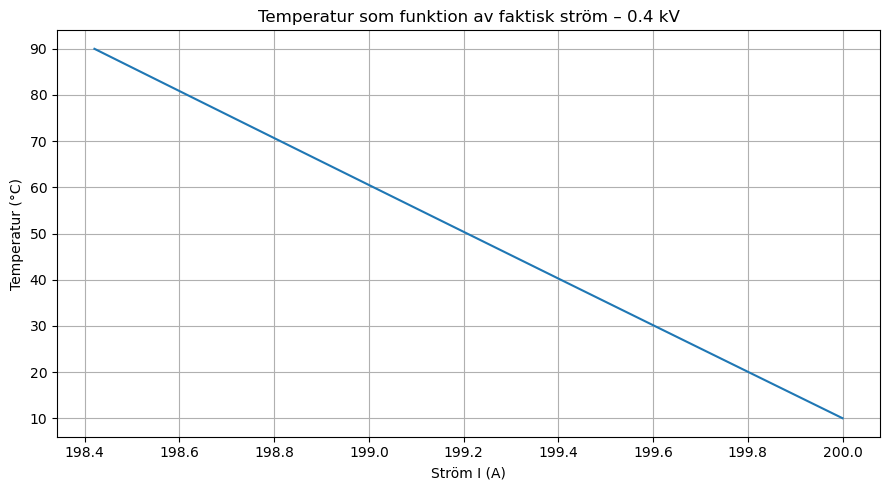

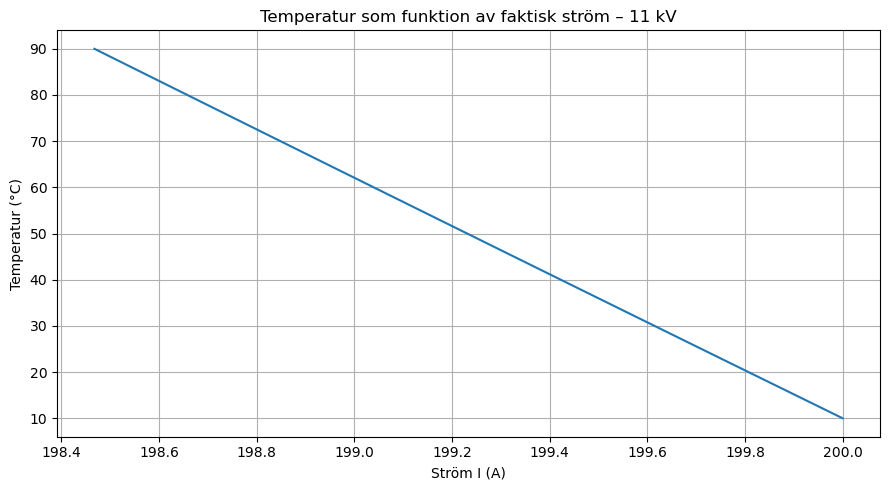

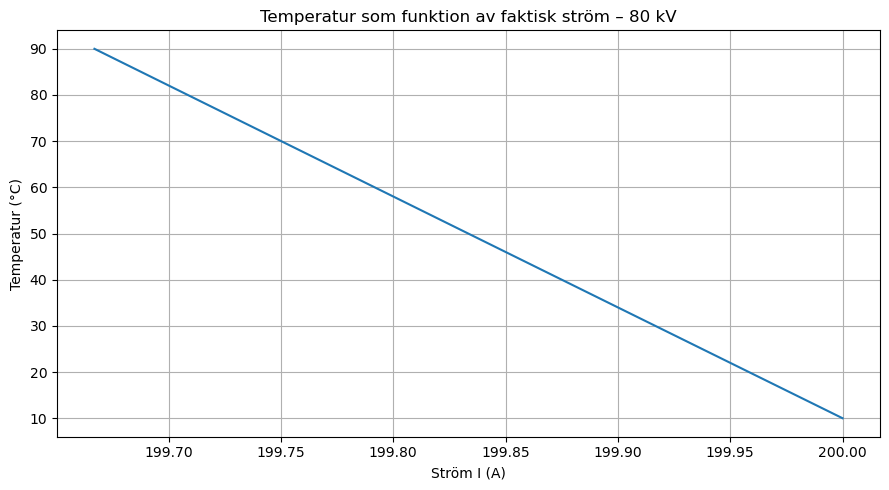

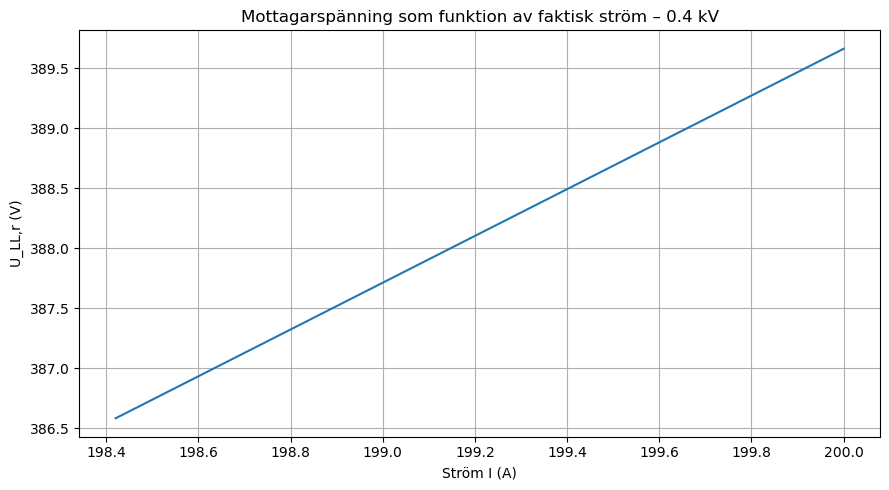

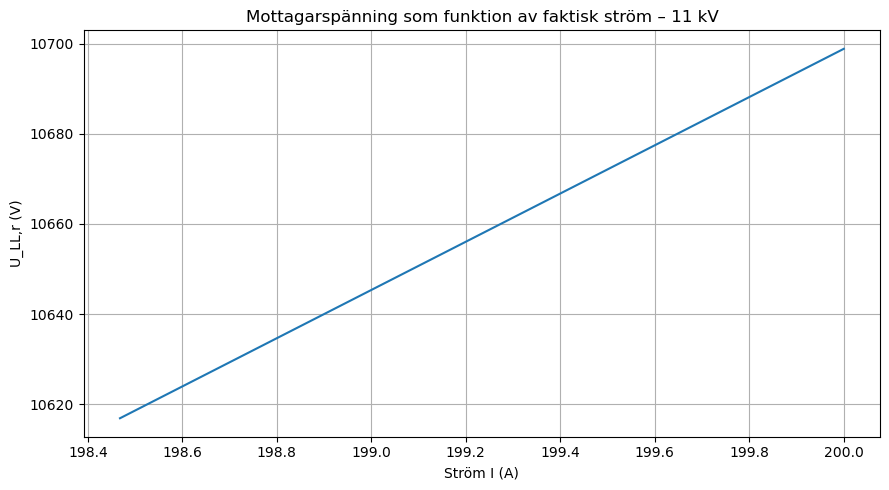

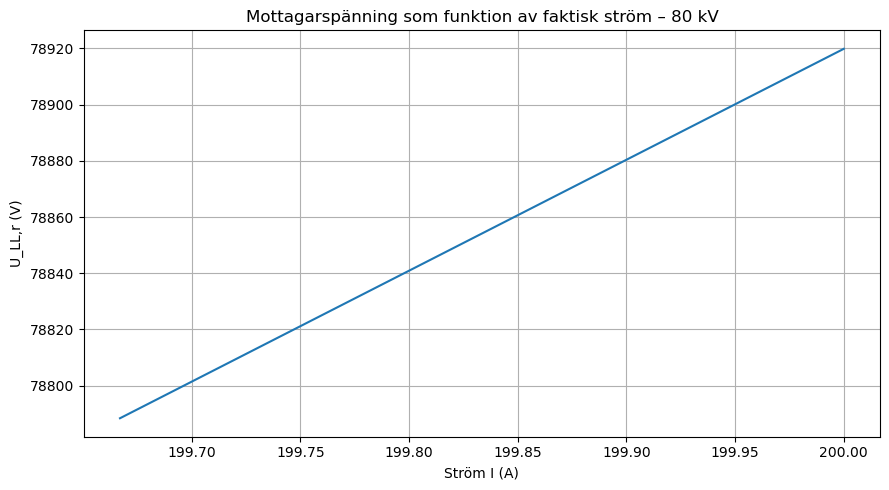

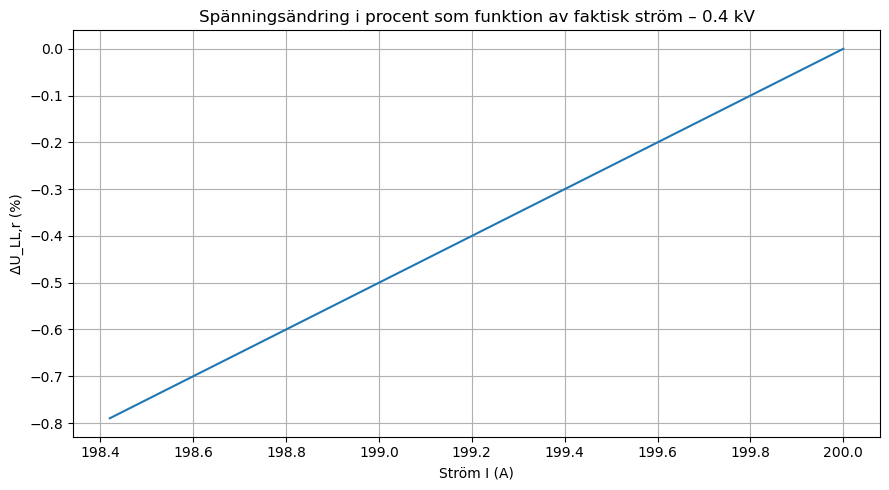

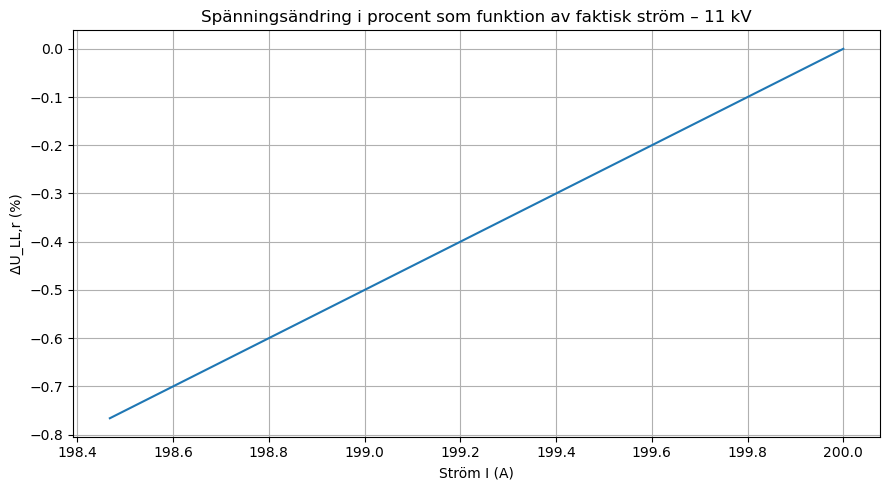

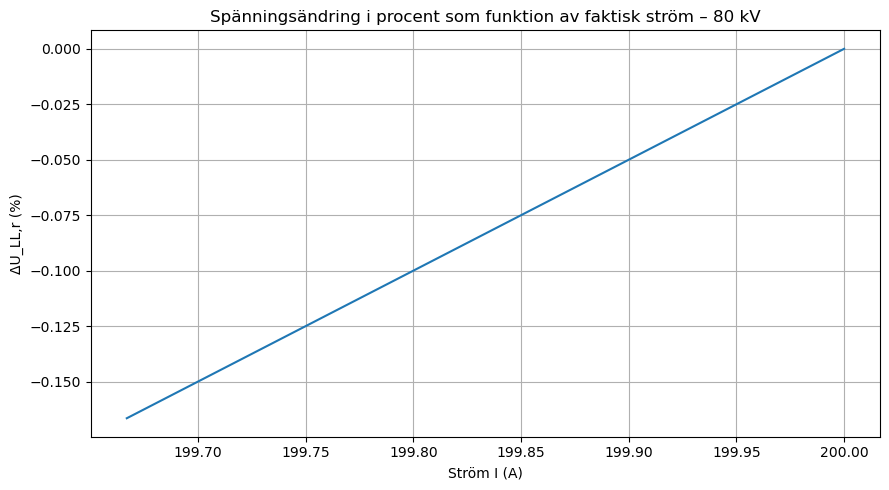

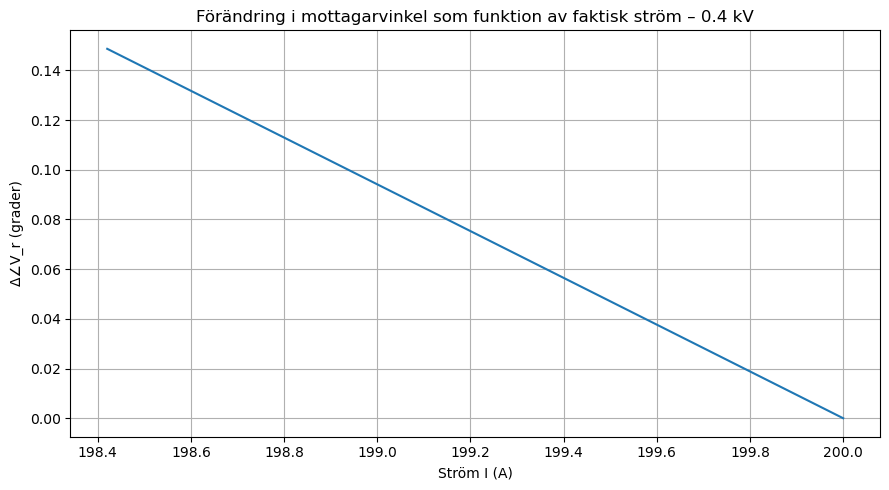

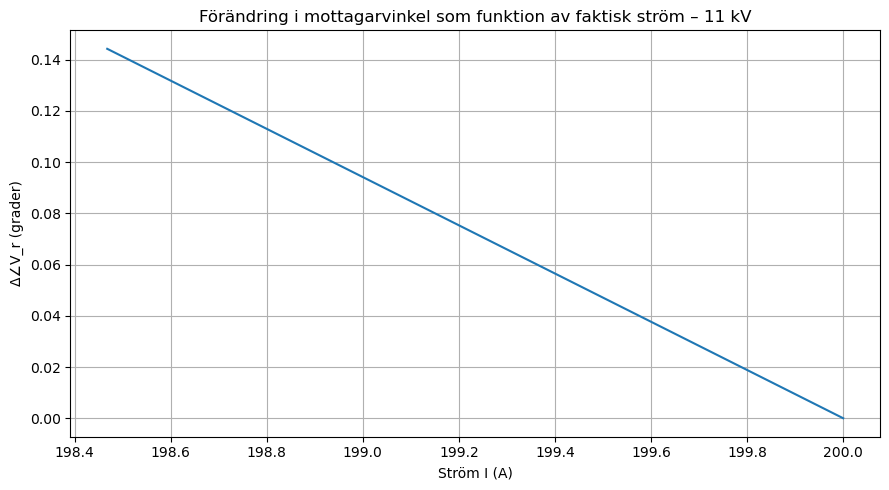

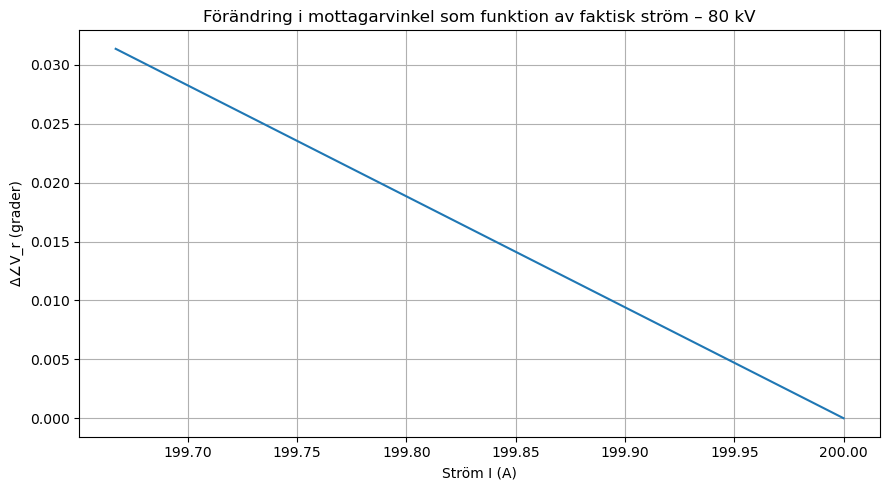

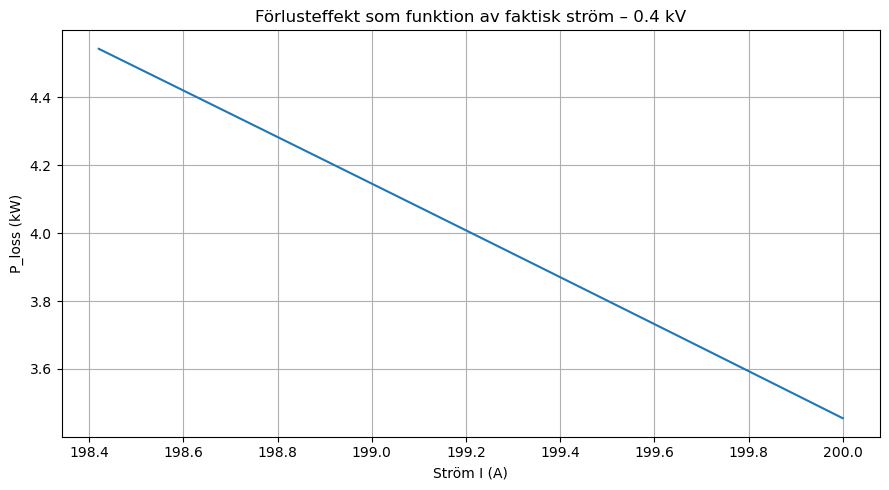

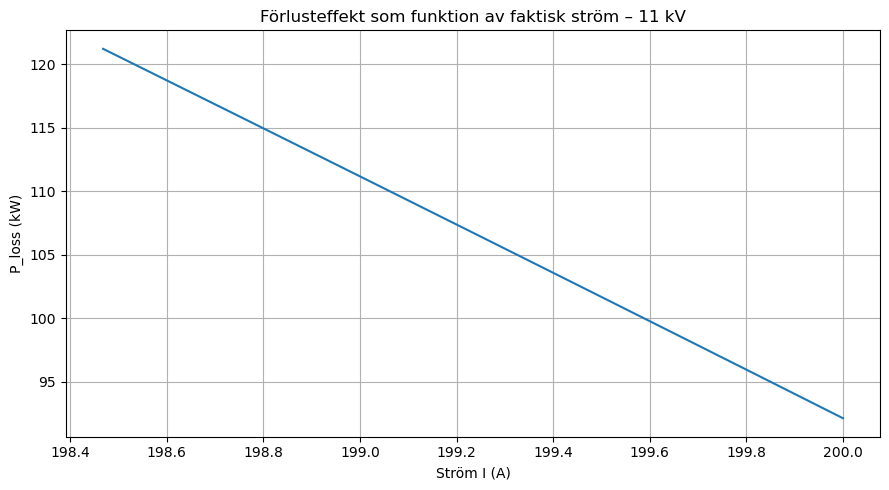

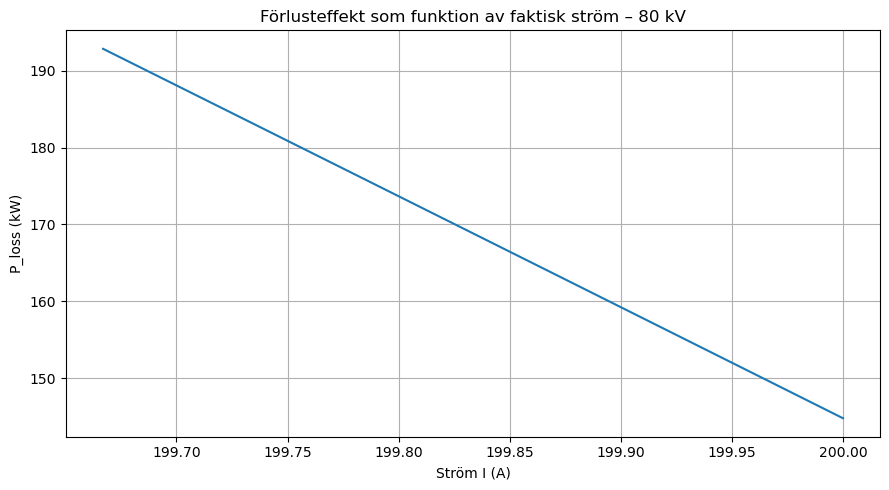


=== SAMMANFATTNING: BEFINTLIG FAST-LOAD MED STRÖM PÅ X-AXEL ===
  Exempel  I_10C_A     I_90C_A  Delta_I_A  T_10C  T_90C  \
0  0.4 kV    200.0  198.420418  -1.579582     10     90   
1   11 kV    200.0  198.467937  -1.532063     10     90   
2   80 kV    200.0  199.666978  -0.333022     10     90   

   Delta_Vr_pct_90C_rel_10C  Delta_Vr_angle_deg_90C_rel_10C  P_loss_10C_kW  \
0                 -0.789791                        0.148672        3.45492   
1                 -0.766031                        0.144201       92.13120   
2                 -0.166511                        0.031355      144.81873   

   P_loss_90C_kW  
0       4.542941  
1     121.203135  
2     192.825133  

Allt sparat till: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\10-90_grader_fast_last_current_x_only


In [4]:
# ============================================================
# ENDAST OMSKALNING:
# Använd faktisk ström I(T) på x-axeln
# Inget nytt strömsvep
# ============================================================

import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def safe_folder_name(name):
    return re.sub(r'[<>:"/\\|?*]', '_', name).strip().rstrip(".")

# ============================================================
# SPARA
# ============================================================

VERSION = "10-90_grader_fast_last_current_x_only"

try:
    base_dir = output_dir.parent
except NameError:
    base_dir = Path(
        r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data"
    )

output_dir_current_x = base_dir / safe_folder_name(VERSION)
output_dir_current_x.mkdir(parents=True, exist_ok=True)

print("Sparar till:", output_dir_current_x.resolve())

# ============================================================
# LÄGG TILL RELATIVA KOLUMNER
# ============================================================

def add_current_axis_columns(df):
    df = df.copy()
    row10 = df[df["T_C"] == 10].iloc[0]

    df["Delta_Vr_V_rel_10C"] = df["Vr_LL_exact_V"] - row10["Vr_LL_exact_V"]
    df["Delta_Vr_pct_rel_10C"] = 100.0 * df["Delta_Vr_V_rel_10C"] / row10["Vr_LL_exact_V"]
    df["Delta_Vr_ang_deg_rel_10C"] = df["Vr_ang_exact_deg"] - row10["Vr_ang_exact_deg"]
    df["Delta_P_loss_kW_rel_10C"] = (df["P_loss_W"] - row10["P_loss_W"]) / 1000.0

    return df

df_04_I = add_current_axis_columns(df_04)
df_11_I = add_current_axis_columns(df_11)
df_80_I = add_current_axis_columns(df_80)

cases = [
    ("0.4 kV", df_04_I, "0_4kV"),
    ("11 kV", df_11_I, "11kV"),
    ("80 kV", df_80_I, "80kV"),
]

# Spara datatabeller
df_04_I.to_excel(output_dir_current_x / "current_x_only_0_4kV.xlsx", index=False)
df_11_I.to_excel(output_dir_current_x / "current_x_only_11kV.xlsx", index=False)
df_80_I.to_excel(output_dir_current_x / "current_x_only_80kV.xlsx", index=False)

# ============================================================
# 1. Temperatur som funktion av faktisk ström
# ============================================================

for label, df_case, tag in cases:
    df_plot = df_case.sort_values("I_A_exact")

    plt.figure(figsize=(9, 5))
    plt.plot(df_plot["I_A_exact"], df_plot["T_C"])
    plt.title(f"Temperatur som funktion av faktisk ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("Temperatur (°C)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir_current_x / f"T_vs_current_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# 2. Mottagarspänning som funktion av faktisk ström
# ============================================================

for label, df_case, tag in cases:
    df_plot = df_case.sort_values("I_A_exact")

    plt.figure(figsize=(9, 5))
    plt.plot(df_plot["I_A_exact"], df_plot["Vr_LL_exact_V"])
    plt.title(f"Mottagarspänning som funktion av faktisk ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("U_LL,r (V)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir_current_x / f"Vr_vs_current_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# 3. Spänningsändring i procent som funktion av faktisk ström
# ============================================================

for label, df_case, tag in cases:
    df_plot = df_case.sort_values("I_A_exact")

    plt.figure(figsize=(9, 5))
    plt.plot(df_plot["I_A_exact"], df_plot["Delta_Vr_pct_rel_10C"])
    plt.title(f"Spänningsändring i procent som funktion av faktisk ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("ΔU_LL,r (%)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir_current_x / f"Delta_Vr_pct_vs_current_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# 4. Mottagarvinkeländring som funktion av faktisk ström
# ============================================================

for label, df_case, tag in cases:
    df_plot = df_case.sort_values("I_A_exact")

    plt.figure(figsize=(9, 5))
    plt.plot(df_plot["I_A_exact"], df_plot["Delta_Vr_ang_deg_rel_10C"])
    plt.title(f"Förändring i mottagarvinkel som funktion av faktisk ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("Δ∠V_r (grader)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir_current_x / f"Delta_Vr_angle_vs_current_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# 5. Förlusteffekt som funktion av faktisk ström
# ============================================================

for label, df_case, tag in cases:
    df_plot = df_case.sort_values("I_A_exact")

    plt.figure(figsize=(9, 5))
    plt.plot(df_plot["I_A_exact"], df_plot["P_loss_W"] / 1000.0)
    plt.title(f"Förlusteffekt som funktion av faktisk ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("P_loss (kW)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir_current_x / f"Ploss_vs_current_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# SAMMANFATTNING
# ============================================================

summary_rows = []

for label, df_case, tag in cases:
    row10 = df_case[df_case["T_C"] == 10].iloc[0]
    row90 = df_case[df_case["T_C"] == 90].iloc[0]

    summary_rows.append({
        "Exempel": label,
        "I_10C_A": row10["I_A_exact"],
        "I_90C_A": row90["I_A_exact"],
        "Delta_I_A": row90["I_A_exact"] - row10["I_A_exact"],
        "T_10C": row10["T_C"],
        "T_90C": row90["T_C"],
        "Delta_Vr_pct_90C_rel_10C": row90["Delta_Vr_pct_rel_10C"],
        "Delta_Vr_angle_deg_90C_rel_10C": row90["Delta_Vr_ang_deg_rel_10C"],
        "P_loss_10C_kW": row10["P_loss_W"] / 1000.0,
        "P_loss_90C_kW": row90["P_loss_W"] / 1000.0,
    })

summary_current_x = pd.DataFrame(summary_rows)

print("\n=== SAMMANFATTNING: BEFINTLIG FAST-LOAD MED STRÖM PÅ X-AXEL ===")
print(summary_current_x.round(6))

summary_current_x.to_excel(output_dir_current_x / "summary_current_x_only.xlsx", index=False)
summary_current_x.to_csv(output_dir_current_x / "summary_current_x_only.csv", index=False)

print("\nAllt sparat till:", output_dir_current_x.resolve())

Sparar till: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\thermal_model_temperature_vs_current

=== 0.4 kV ===
R20 = 0.030000 ohm
X = 0.008000 ohm
theta_th = 3.79152259e-03 °C/W
Kalibrering: 400 A -> 90.0 °C

=== 11 kV ===
R20 = 0.800000 ohm
X = 0.450000 ohm
theta_th = 1.42182097e-04 °C/W
Kalibrering: 400 A -> 90.0 °C

=== 80 kV ===
R20 = 1.257500 ohm
X = 6.555000 ohm
theta_th = 9.04538192e-05 °C/W
Kalibrering: 400 A -> 90.0 °C

=== SAMMANFATTNING TERMISK MODELL ===
   Exempel  I_A        T_C     R_Ohm   P_loss_kW   Delta_Vr_V  Delta_Vr_pct  \
0   0.4 kV    0  20.000000  0.030000    0.000000     0.000000      0.000000   
1   0.4 kV  100  23.459951  0.030418    0.912549    -5.437704     -1.359426   
2   0.4 kV  200  34.444009  0.031746    3.809554   -11.311879     -2.827970   
3   0.4 kV  300  55.049264  0.034237    9.244113   -18.195410     -4.548852   
4   0.4 kV  400  90.000000  0.038463   18.462240   -27.033700     -6.758425   
5  

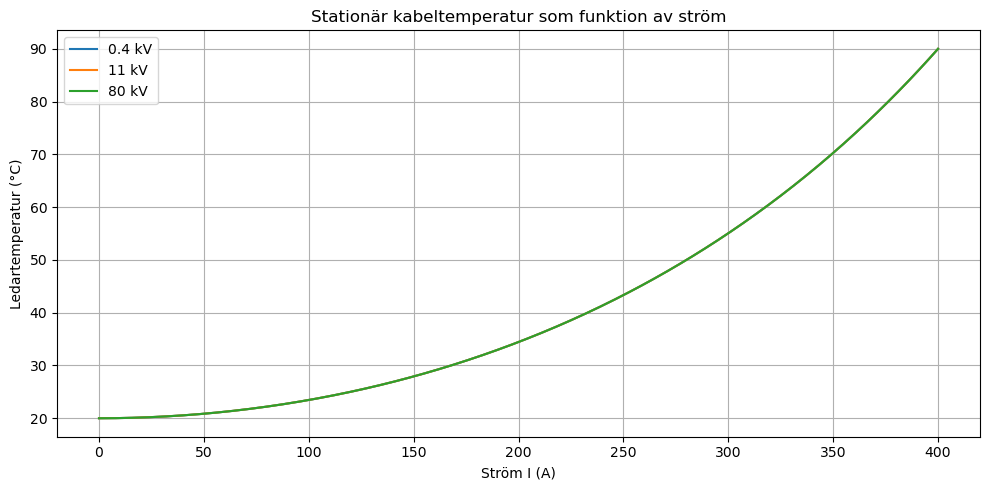

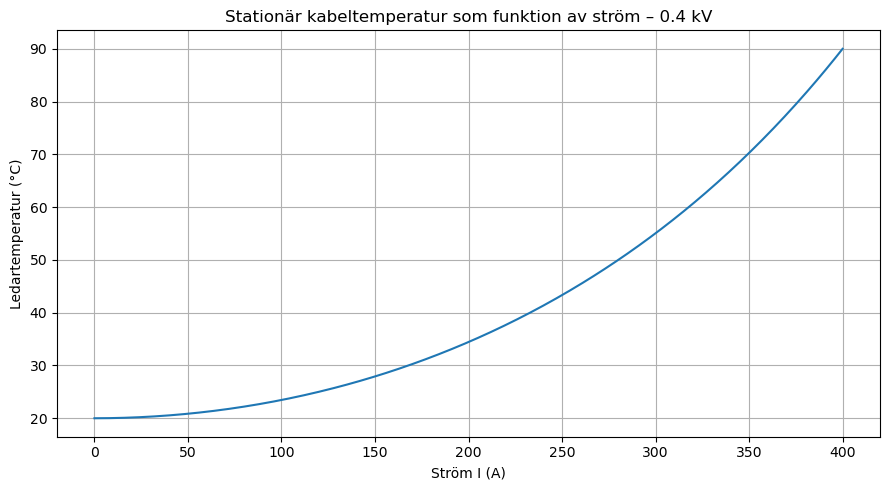

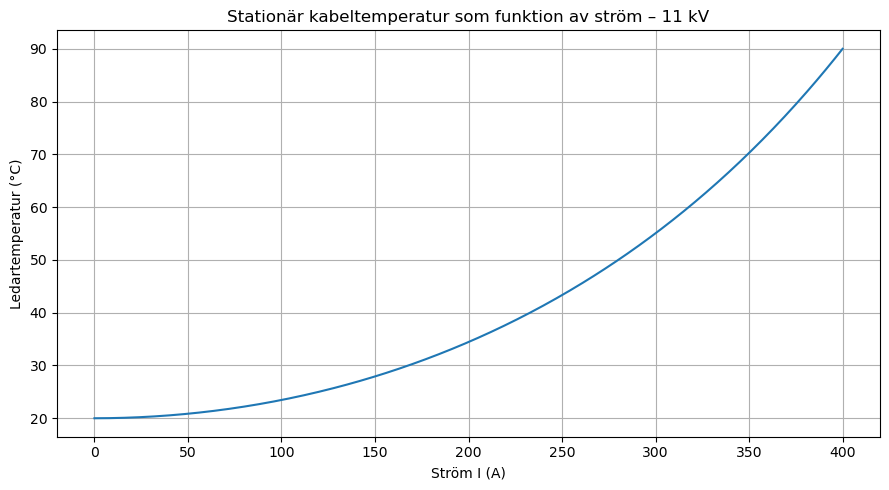

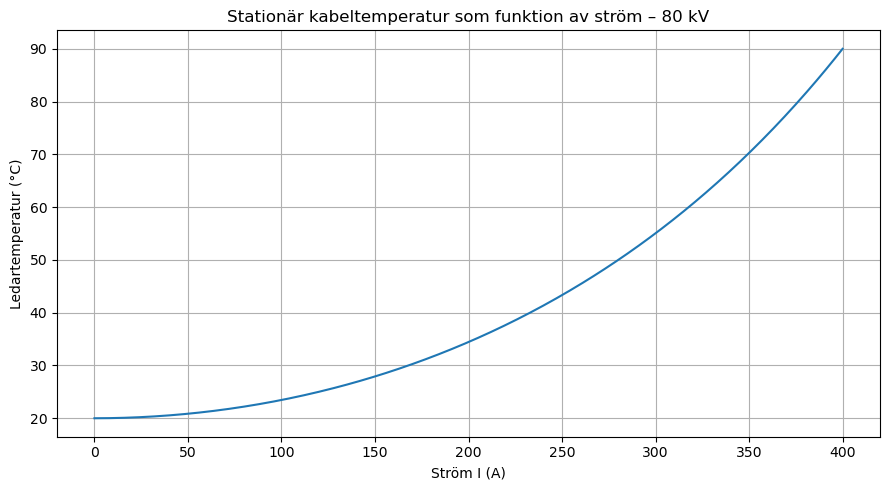

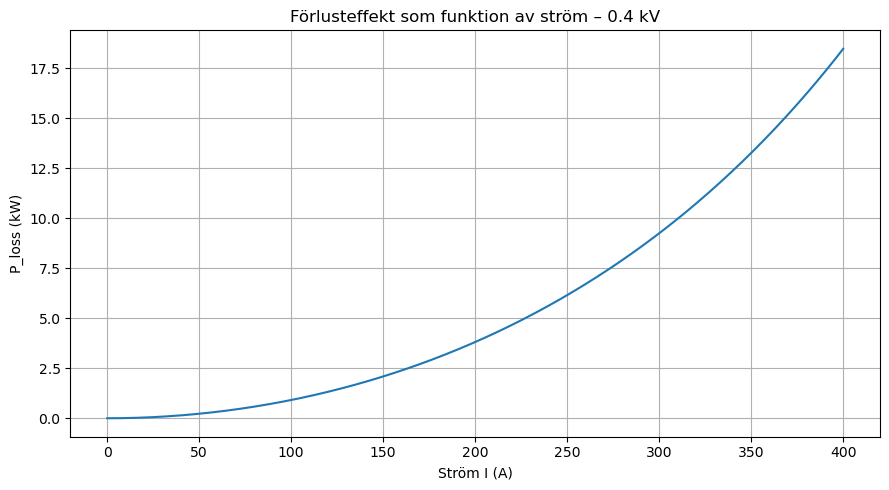

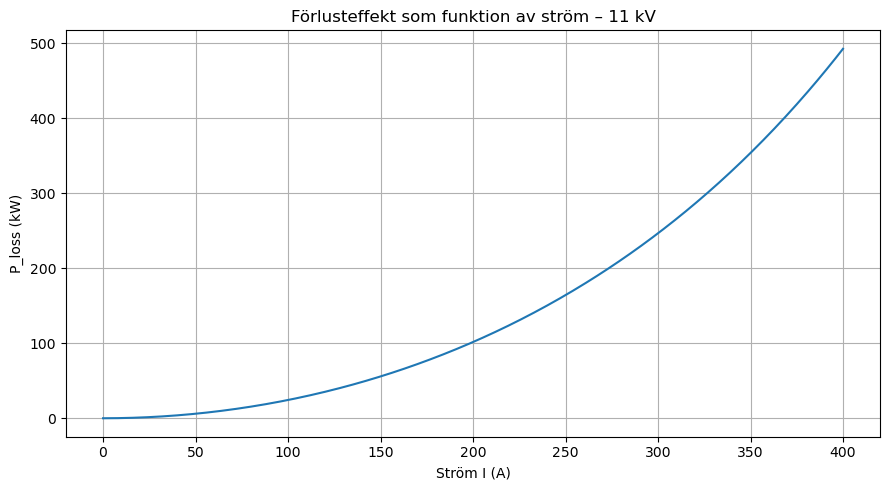

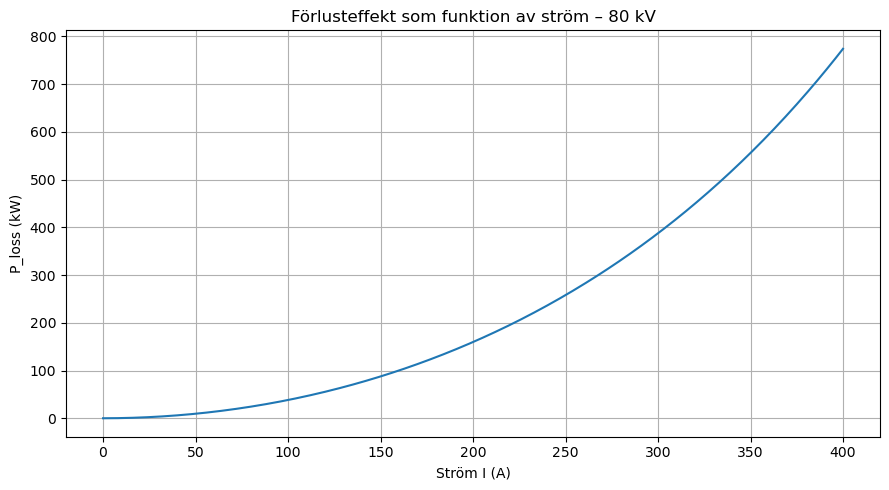

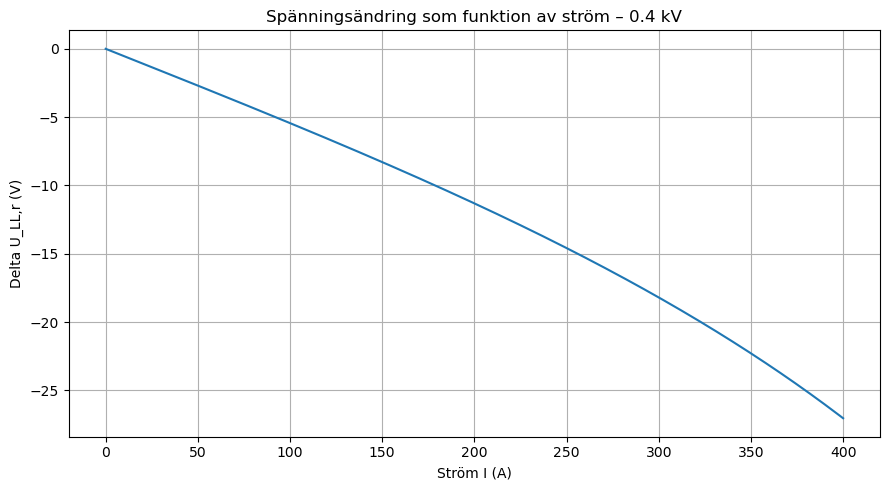

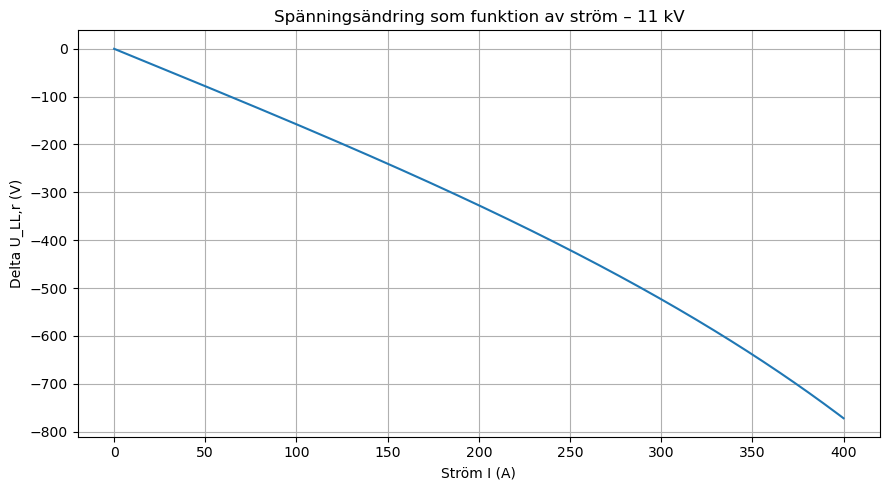

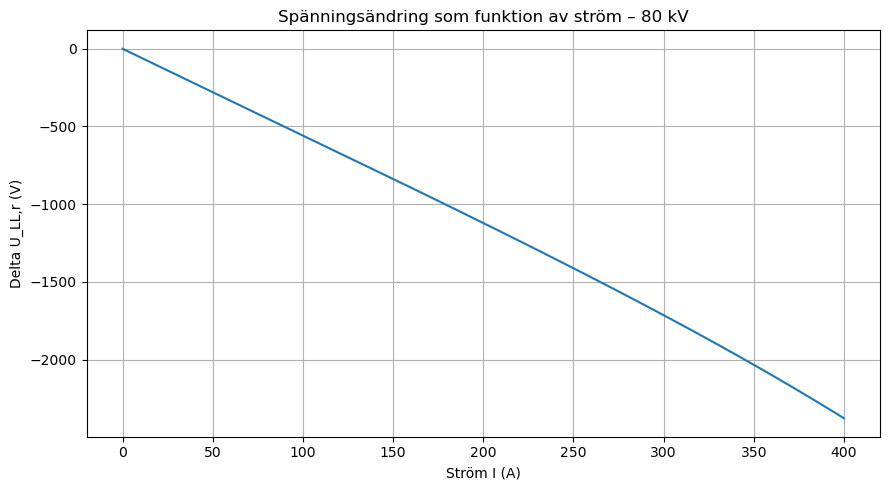

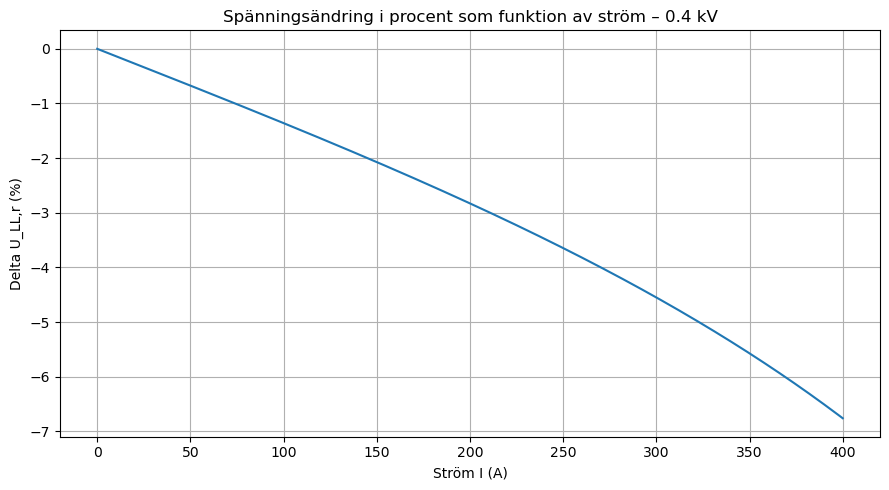

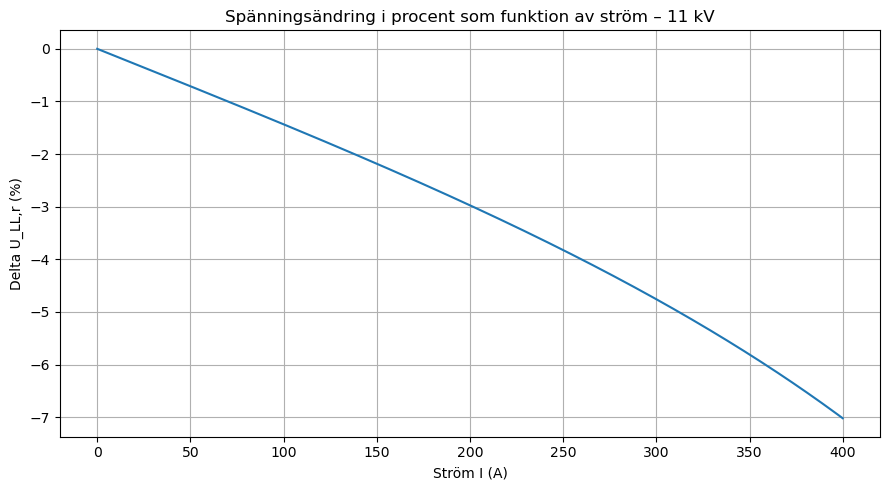

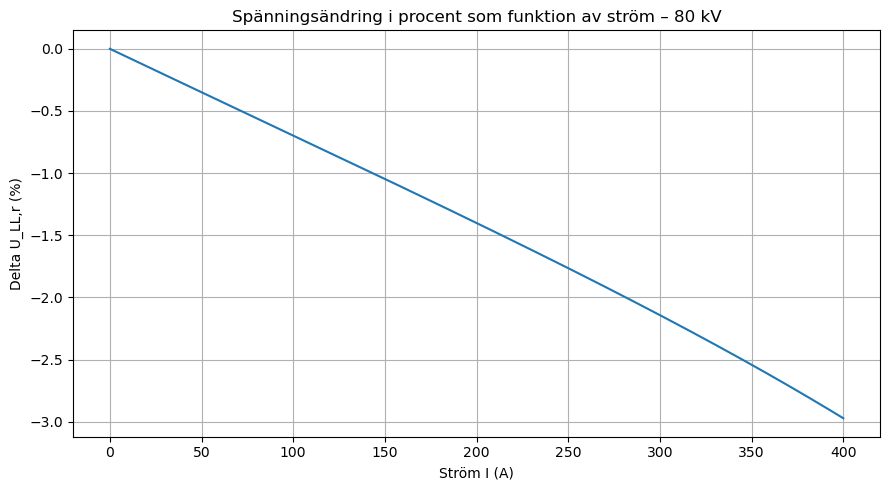

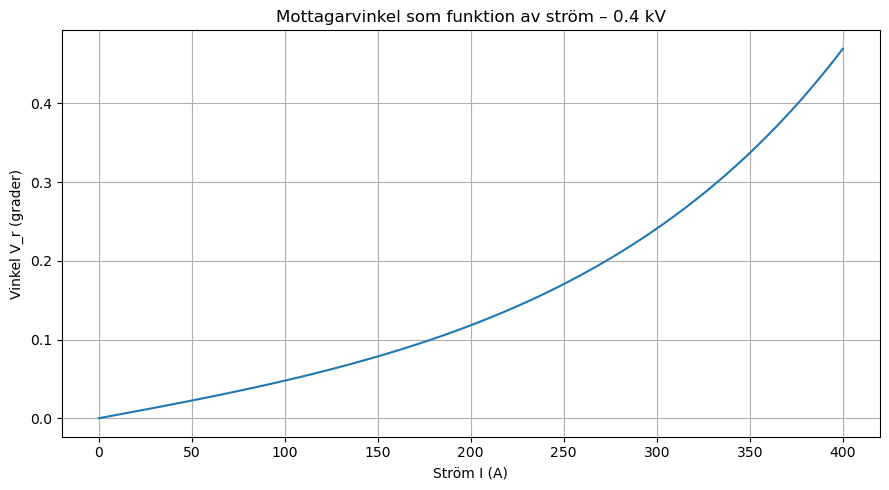

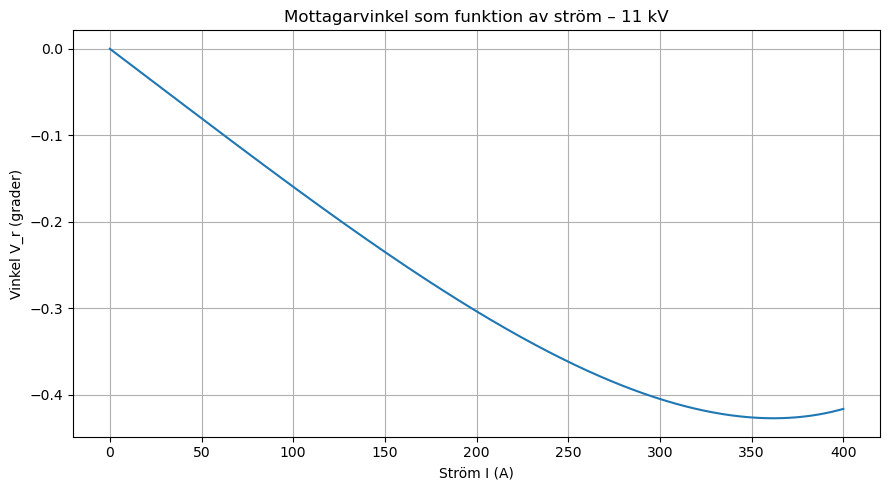

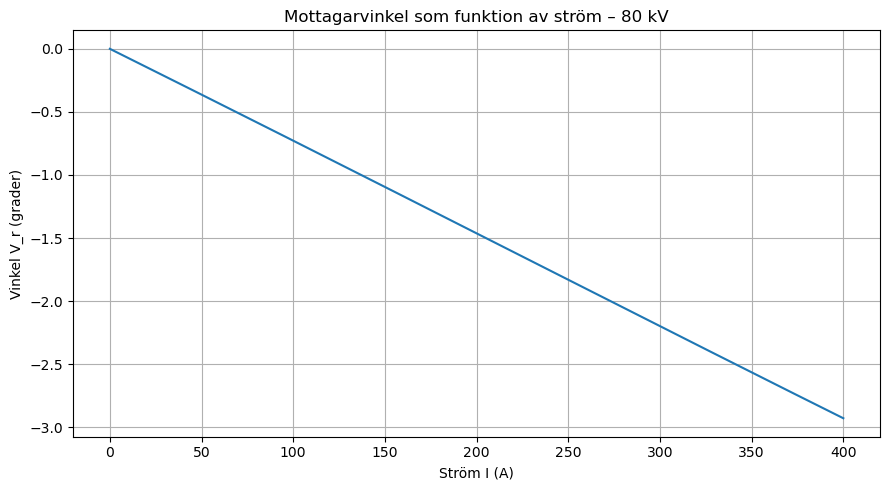

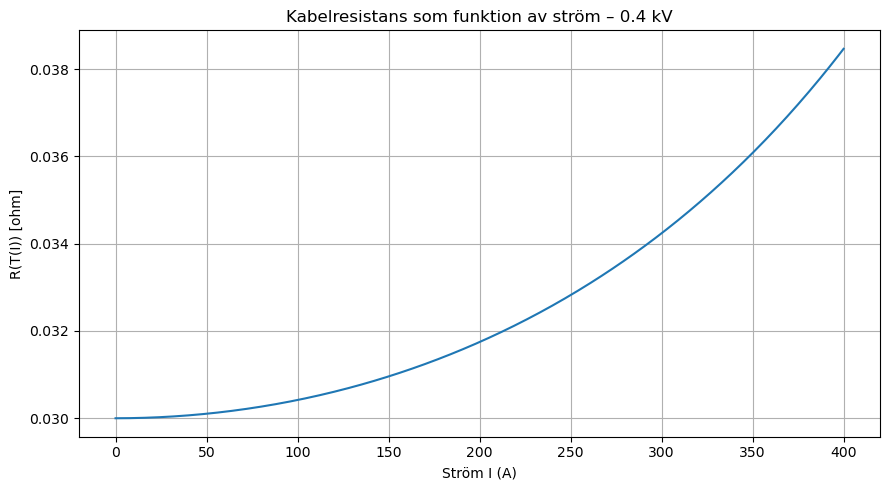

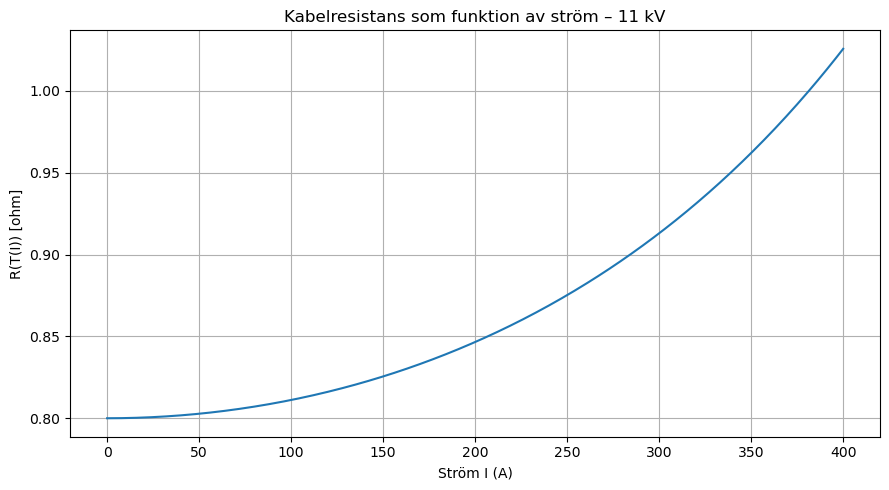

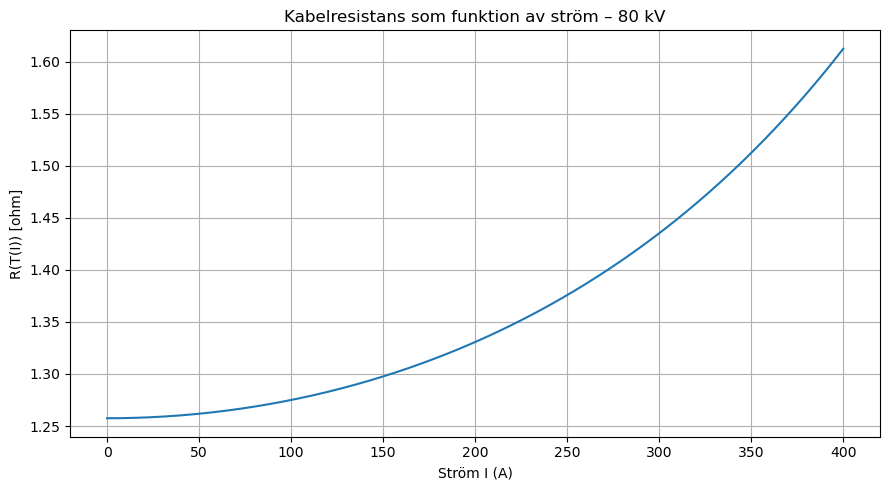


Allt sparat till: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\thermal_model_temperature_vs_current


In [5]:
# ============================================================
# TERMISK MODELL:
# Temperatur som funktion av ström
#
# Syfte:
#   Visa hur kabeltemperaturen kan beräknas från strömmen
#   om man lägger till en enkel stationär termisk modell.
#
# Elektrisk modell:
#   P_loss = 3 * I^2 * R(T)
#
# Termisk modell:
#   T = T_amb + theta_th * P_loss
#
# Eftersom R beror på T löses modellen självkonsekvent.
# ============================================================

import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def safe_folder_name(name):
    return re.sub(r'[<>:"/\\|?*]', "_", name).strip().rstrip(".")

def polar(mag, ang_deg):
    return mag * np.exp(1j * np.deg2rad(ang_deg))

def angle_deg(z):
    return np.rad2deg(np.angle(z))

def R_of_T(R20, T_C, alpha):
    return R20 * (1.0 + alpha * (T_C - 20.0))

def calibrate_theta_th(R20, I_ref_A, T_ref_C, T_amb_C, alpha):
    """
    Kalibrerar theta_th så att kabeln får T_ref_C vid I_ref_A.
    Detta är en förenklad pedagogisk kalibrering.
    """
    R_ref = R_of_T(R20, T_ref_C, alpha)
    P_loss_ref = 3.0 * (I_ref_A ** 2) * R_ref
    theta_th = (T_ref_C - T_amb_C) / P_loss_ref
    return theta_th

def solve_steady_temperature(I_A, R20, theta_th, T_amb_C, alpha):
    """
    Löser stationär temperatur:

    T = T_amb + theta_th * 3 * I^2 * R20 * (1 + alpha*(T - 20))

    Eftersom uttrycket är linjärt i T kan det lösas direkt.
    """

    K = theta_th * 3.0 * (I_A ** 2) * R20
    denominator = 1.0 - K * alpha

    if denominator <= 0:
        return np.nan

    T_C = (T_amb_C + K * (1.0 - alpha * 20.0)) / denominator
    return T_C

# ============================================================
# PARAMETRAR
# ============================================================

alpha = 0.00403

# Omgivningstemperatur
T_amb_C = 20.0

# Kalibreringspunkt:
# Här tvingas modellen ge 90 °C vid 400 A.
# Ändra dessa om du vill testa annan termisk nivå.
I_cal_A = 400.0
T_cal_C = 90.0

# Strömsvep
I_min = 0.0
I_max = 400.0
I_step = 1.0

# Effektfaktor
cosphi = 0.95

# ============================================================
# FALL
# 0.4 kV och 11 kV är illustrativa
# 80 kV är Bohus-likt
# ============================================================

cases = [
    {
        "label": "0.4 kV",
        "tag": "0_4kV",
        "U_LL_s": 400.0,
        "R20": 0.030,
        "X": 0.008,
    },
    {
        "label": "11 kV",
        "tag": "11kV",
        "U_LL_s": 11000.0,
        "R20": 0.800,
        "X": 0.450,
    },
    {
        "label": "80 kV",
        "tag": "80kV",
        "U_LL_s": 80000.0,
        "R20": 1.2575,
        "X": 6.555,
    },
]

# ============================================================
# SPARA
# ============================================================

VERSION = "thermal_model_temperature_vs_current"

try:
    base_dir = output_dir.parent
except NameError:
    base_dir = Path(
        r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data"
    )

output_dir_thermal = base_dir / safe_folder_name(VERSION)
output_dir_thermal.mkdir(parents=True, exist_ok=True)

print("Sparar till:", output_dir_thermal.resolve())

# ============================================================
# MODELLFUNKTION
# ============================================================

def run_thermal_current_model(case):
    label = case["label"]
    tag = case["tag"]
    U_LL_s = case["U_LL_s"]
    R20 = case["R20"]
    X = case["X"]

    # Kalibrera termisk resistans för detta fall
    theta_th = calibrate_theta_th(
        R20=R20,
        I_ref_A=I_cal_A,
        T_ref_C=T_cal_C,
        T_amb_C=T_amb_C,
        alpha=alpha
    )

    phi_deg = np.degrees(np.arccos(cosphi))
    Vs = polar(U_LL_s / np.sqrt(3), 0.0)

    rows = []

    for I_A in np.arange(I_min, I_max + I_step, I_step):
        T_C = solve_steady_temperature(
            I_A=I_A,
            R20=R20,
            theta_th=theta_th,
            T_amb_C=T_amb_C,
            alpha=alpha
        )

        if np.isnan(T_C):
            rows.append({
                "Exempel": label,
                "I_A": I_A,
                "T_C": np.nan,
                "R_Ohm": np.nan,
                "X_Ohm": X,
                "P_loss_W": np.nan,
                "P_loss_kW": np.nan,
                "U_LL_s_V": U_LL_s,
                "Vr_LL_V": np.nan,
                "Delta_Vr_V": np.nan,
                "Delta_Vr_pct": np.nan,
                "Vr_ang_deg": np.nan,
                "theta_th_C_per_W": theta_th,
            })
            continue

        R = R_of_T(R20, T_C, alpha)
        Z = R + 1j * X

        Iph = polar(I_A, -phi_deg)
        Vr = Vs - Z * Iph

        P_loss = 3.0 * (I_A ** 2) * R

        Vr_LL = abs(Vr) * np.sqrt(3)
        Delta_Vr_V = Vr_LL - U_LL_s
        Delta_Vr_pct = 100.0 * Delta_Vr_V / U_LL_s

        rows.append({
            "Exempel": label,
            "I_A": I_A,
            "T_C": T_C,
            "R_Ohm": R,
            "X_Ohm": X,
            "P_loss_W": P_loss,
            "P_loss_kW": P_loss / 1000.0,
            "U_LL_s_V": U_LL_s,
            "Vr_LL_V": Vr_LL,
            "Delta_Vr_V": Delta_Vr_V,
            "Delta_Vr_pct": Delta_Vr_pct,
            "Vr_ang_deg": angle_deg(Vr),
            "theta_th_C_per_W": theta_th,
        })

    df = pd.DataFrame(rows)

    print(f"\n=== {label} ===")
    print(f"R20 = {R20:.6f} ohm")
    print(f"X = {X:.6f} ohm")
    print(f"theta_th = {theta_th:.8e} °C/W")
    print(f"Kalibrering: {I_cal_A:.0f} A -> {T_cal_C:.1f} °C")

    return df

# ============================================================
# KÖR MODELLEN
# ============================================================

results = {}

for case in cases:
    df_case = run_thermal_current_model(case)
    results[case["label"]] = df_case

    df_case.to_excel(
        output_dir_thermal / f"thermal_current_model_{case['tag']}.xlsx",
        index=False
    )

    df_case.to_csv(
        output_dir_thermal / f"thermal_current_model_{case['tag']}.csv",
        index=False
    )

df_all = pd.concat(results.values(), ignore_index=True)

df_all.to_excel(output_dir_thermal / "thermal_current_model_all.xlsx", index=False)
df_all.to_csv(output_dir_thermal / "thermal_current_model_all.csv", index=False)

# ============================================================
# SAMMANFATTNING VID UTVALDA STRÖMMAR
# ============================================================

selected_currents = [0, 100, 200, 300, 400]

summary_rows = []

for case in cases:
    label = case["label"]
    df_case = results[label]

    for I_pick in selected_currents:
        row = df_case[df_case["I_A"] == I_pick].iloc[0]

        summary_rows.append({
            "Exempel": label,
            "I_A": I_pick,
            "T_C": row["T_C"],
            "R_Ohm": row["R_Ohm"],
            "P_loss_kW": row["P_loss_kW"],
            "Delta_Vr_V": row["Delta_Vr_V"],
            "Delta_Vr_pct": row["Delta_Vr_pct"],
            "Vr_ang_deg": row["Vr_ang_deg"],
            "theta_th_C_per_W": row["theta_th_C_per_W"],
        })

summary_thermal = pd.DataFrame(summary_rows)

print("\n=== SAMMANFATTNING TERMISK MODELL ===")
print(summary_thermal.round(6))

summary_thermal.to_excel(
    output_dir_thermal / "summary_thermal_model_selected_currents.xlsx",
    index=False
)

summary_thermal.to_csv(
    output_dir_thermal / "summary_thermal_model_selected_currents.csv",
    index=False
)

# ============================================================
# FIGUR 1: TEMPERATUR SOM FUNKTION AV STRÖM
# ============================================================

plt.figure(figsize=(10, 5))

for case in cases:
    label = case["label"]
    df_case = results[label]
    plt.plot(df_case["I_A"], df_case["T_C"], label=label)

plt.title("Stationär kabeltemperatur som funktion av ström")
plt.xlabel("Ström I (A)")
plt.ylabel("Ledartemperatur (°C)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir_thermal / "T_vs_I_all.png", dpi=200)
plt.show()

# Separata temperaturgrafer
for case in cases:
    label = case["label"]
    tag = case["tag"]
    df_case = results[label]

    plt.figure(figsize=(9, 5))
    plt.plot(df_case["I_A"], df_case["T_C"])
    plt.title(f"Stationär kabeltemperatur som funktion av ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("Ledartemperatur (°C)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir_thermal / f"T_vs_I_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# FIGUR 2: FÖRLUSTEFFEKT SOM FUNKTION AV STRÖM
# ============================================================

for case in cases:
    label = case["label"]
    tag = case["tag"]
    df_case = results[label]

    plt.figure(figsize=(9, 5))
    plt.plot(df_case["I_A"], df_case["P_loss_kW"])
    plt.title(f"Förlusteffekt som funktion av ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("P_loss (kW)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir_thermal / f"Ploss_vs_I_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# FIGUR 3: SPÄNNINGSÄNDRING SOM FUNKTION AV STRÖM
# ============================================================

for case in cases:
    label = case["label"]
    tag = case["tag"]
    df_case = results[label]

    plt.figure(figsize=(9, 5))
    plt.plot(df_case["I_A"], df_case["Delta_Vr_V"])
    plt.title(f"Spänningsändring som funktion av ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("Delta U_LL,r (V)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir_thermal / f"Delta_Vr_vs_I_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# FIGUR 4: SPÄNNINGSÄNDRING I PROCENT SOM FUNKTION AV STRÖM
# ============================================================

for case in cases:
    label = case["label"]
    tag = case["tag"]
    df_case = results[label]

    plt.figure(figsize=(9, 5))
    plt.plot(df_case["I_A"], df_case["Delta_Vr_pct"])
    plt.title(f"Spänningsändring i procent som funktion av ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("Delta U_LL,r (%)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir_thermal / f"Delta_Vr_pct_vs_I_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# FIGUR 5: MOTTAGARVINKEL SOM FUNKTION AV STRÖM
# ============================================================

for case in cases:
    label = case["label"]
    tag = case["tag"]
    df_case = results[label]

    plt.figure(figsize=(9, 5))
    plt.plot(df_case["I_A"], df_case["Vr_ang_deg"])
    plt.title(f"Mottagarvinkel som funktion av ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("Vinkel V_r (grader)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir_thermal / f"Vr_angle_vs_I_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# FIGUR 6: RESISTANS SOM FUNKTION AV STRÖM
# ============================================================

for case in cases:
    label = case["label"]
    tag = case["tag"]
    df_case = results[label]

    plt.figure(figsize=(9, 5))
    plt.plot(df_case["I_A"], df_case["R_Ohm"])
    plt.title(f"Kabelresistans som funktion av ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("R(T(I)) [ohm]")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir_thermal / f"R_vs_I_{tag}.png", dpi=200)
    plt.show()

print("\nAllt sparat till:", output_dir_thermal.resolve())